# Bitcoin Crash Detection Using Fear & Greed Index
## DAT 402 — Project 2
### Name: Aditya Bohra

---

## 1. Introduction and Problem Definition

Bitcoin is the world's largest cryptocurrency by market capitalization, 
known for its extreme price volatility and dramatic boom-bust cycles. 
Unlike traditional assets such as stocks or bonds, Bitcoin has no 
underlying fundamentals — no earnings, no dividends, no book value. 
Its price is driven almost entirely by market sentiment and speculation.

This project investigates a central question in cryptocurrency finance:

> **Can market psychology — specifically the Crypto Fear & Greed Index 
— help predict Bitcoin price crashes before they happen?**

### Why This Question Matters

Bitcoin's price history shows a recurring pattern — periods of extreme 
optimism (greed) are consistently followed by sharp price corrections. 
This observation motivates our hypothesis: that quantifying market 
emotion through the Fear & Greed Index may provide an early warning 
signal for crash risk.

### Two Methods Used

- **Method 1 — Regression:** Ridge Regression and Random Forest 
Regressor to predict next day Bitcoin returns
- **Method 2 — Classification:** Logistic Regression and XGBoost 
to detect crash days (drops exceeding 5%)

In [1]:
# We are importing all the tools (libraries) we need for this project

import yfinance as yf      # yfinance lets us download stock/crypto price data from Yahoo Finance
import pandas as pd        # pandas is for working with tables of data (like Excel but in Python)
import numpy as np         # numpy is for math operations (averages, calculations etc.)
import requests            # requests lets us call APIs (we'll use this to get Fear & Greed data)
from datetime import datetime  # datetime helps us work with dates
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')  # this just hides unnecessary warning messages

print("All libraries loaded successfully!")  # confirms everything imported without errors

All libraries loaded successfully!


## 2. Dataset Description

### Data Sources

| Dataset | Source | Period | Rows |
|---|---|---|---|
| Bitcoin Daily Price | Yahoo Finance via `yfinance` | Jun 2019 – Apr 2026 | 2,497 |
| Crypto Fear & Greed Index | alternative.me API | Jun 2019 – Apr 2026 | 2,497 |

### Bitcoin Price Data (yfinance)
- **Variables:** Open, High, Low, Close, Volume, Daily Return
- **Frequency:** Daily
- **Source:** Yahoo Finance — industry standard financial data provider
- **Link:** https://finance.yahoo.com/quote/BTC-USD

### Crypto Fear & Greed Index (alternative.me)
- **Variables:** Score (0-100), Label (Extreme Fear/Fear/Greed/Extreme Greed)
- **Frequency:** Daily
- **Source:** alternative.me — aggregates 6 market signals into one score
- **Link:** https://alternative.me/crypto/fear-and-greed-index/
- **Components:** Volatility (25%), Market Momentum (25%), 
Social Media (15%), Surveys (15%), Bitcoin Dominance (10%), 
Google Trends (10%)

### Score Interpretation

| Score | Label |
|---|---|
| 0 – 24 | Extreme Fear |
| 25 – 49 | Fear |
| 50 – 74 | Greed |
| 75 – 100 | Extreme Greed |

### Final Merged Dataset
- **Total observations:** 2,497 daily records
- **Missing values:** 0 (after inner join on date)
- **Date range:** June 13, 2019 to April 14, 2026

In [2]:
# -------------------------------------------------------
# WHAT THIS DOES:
# Downloads Bitcoin's daily price history from Yahoo Finance
# Think of it like downloading a spreadsheet of BTC prices
# -------------------------------------------------------

btc = yf.download("BTC-USD",       # "BTC-USD" is the ticker symbol for Bitcoin in US dollars
                   start="2019-06-12",  # start date — we go back to 2018 for enough data
                   end="2026-04-16")    # end date

# yfinance gives us columns with capital letters — we rename them to lowercase
# this is just cleaner and easier to type later
btc = btc[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
btc.columns = ['open', 'high', 'low', 'close', 'volume']
#   open   = price at start of day
#   high   = highest price that day
#   low    = lowest price that day
#   close  = price at end of day (this is the one we use most)
#   volume = how many bitcoins were traded that day

btc.index.name = 'date'  # rename the index (row labels) to 'date' for clarity

# Calculate daily return = how much % did BTC go up or down each day?
# Formula: (today's price - yesterday's price) / yesterday's price
# pct_change() does this automatically
btc['daily_return'] = btc['close'].pct_change()
# Example: if BTC was $20,000 yesterday and $21,000 today
#          daily_return = (21000-20000)/20000 = 0.05 = 5% gain

print(f"BTC data shape: {btc.shape}")          # tells us how many rows and columns
print(f"Date range: {btc.index.min()} to {btc.index.max()}")  # confirms date range
btc.head()  # shows first 5 rows so we can visually check the data looks right

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed

BTC data shape: (2500, 6)
Date range: 2019-06-12 00:00:00 to 2026-04-15 00:00:00


,open,high,low,close,volume,daily_return
date,,,,,,
2019-06-12,7925.434082,8196.648438,7862.359863,8145.857422,19034432883,NaN
2019-06-13,8145.545410,8311.567383,8087.061035,8230.923828,18669407147,0.010443
2019-06-14,8230.898438,8710.636719,8183.393066,8693.833008,19831162906,0.056240
2019-06-15,8689.746094,8859.127930,8618.395508,8838.375000,18371033226,0.016626
2019-06-16,8841.440430,9335.867188,8814.556641,8994.488281,23348550311,0.017663


In [3]:
btc.tail()

,open,high,low,close,volume,daily_return
date,,,,,,
2026-04-11,72976.125000,73784.234375,72556.335938,73054.273438,23287073965,0.001031
2026-04-12,73056.046875,73154.031250,70540.570312,70753.406250,29882740487,-0.031495
2026-04-13,70757.617188,74896.312500,70588.523438,74484.640625,52278211554,0.052736
2026-04-14,74478.398438,76061.757812,73877.203125,74181.609375,53540826530,-0.004068
2026-04-15,74182.023438,75409.273438,73549.203125,74805.078125,38090174312,0.008405


In [4]:
# -------------------------------------------------------
# WHAT THIS DOES:
# Downloads the Crypto Fear & Greed Index
# This is a score from 0 to 100 that measures market emotion
#   0-24  = Extreme Fear  (people are panicking, selling)
#   25-49 = Fear
#   50-74 = Greed
#   75-100 = Extreme Greed (people are overconfident, buying)
# This is a FREE public API — no account or key needed
# -------------------------------------------------------

url = "https://api.alternative.me/fng/?limit=2500&format=json"
# limit=2500 means get last 2500 days of data

response = requests.get(url)   # calls the API
data = response.json()         # converts response to Python dictionary

# Convert to dataframe
fg = pd.DataFrame(data['data'])

# The date comes as Unix timestamp (seconds since 1970)
# we convert it to a readable date
fg['date'] = pd.to_datetime(fg['timestamp'], unit='s')

# Convert score from text to integer
fg['fear_greed'] = fg['value'].astype(int)

# Keep the label too (e.g "Extreme Fear", "Greed" etc.)
fg['fg_label'] = fg['value_classification']

# Keep only columns we need
fg = fg[['date', 'fear_greed', 'fg_label']].set_index('date')

# Remove time part from date so it matches BTC dates when we merge
fg.index = fg.index.normalize()

# Sort from oldest to newest (same direction as BTC data)
fg = fg.sort_index(ascending=True)

print(f"Fear & Greed shape: {fg.shape}")
print(f"Date range: {fg.index.min()} to {fg.index.max()}")
fg.head()

Fear & Greed shape: (2500, 2)
Date range: 2019-06-26 00:00:00 to 2026-04-30 00:00:00


,fear_greed,fg_label
date,,
2019-06-26,95,Extreme Greed
2019-06-27,92,Extreme Greed
2019-06-28,62,Greed
2019-06-29,74,Greed
2019-06-30,78,Extreme Greed


In [5]:
fg.tail()

,fear_greed,fg_label
date,,
2026-04-26,33,Fear
2026-04-27,47,Neutral
2026-04-28,33,Fear
2026-04-29,26,Fear
2026-04-30,29,Fear


In [6]:
# -------------------------------------------------------
# WHAT THIS DOES:
# Merges BTC price + Fear & Greed using INNER JOIN
# Inner join = only keeps dates where BOTH datasets
# have real actual data
# The 2 day difference (Apr 14 vs Apr 16) is handled
# automatically — it just keeps up to Apr 14
# -------------------------------------------------------

df = btc.join(fg, how='inner')

print(f"Shape after merge: {df.shape}")
print(f"Date range: {df.index.min()} to {df.index.max()}")
print(f"\nMissing values per column:")
print(df.isnull().sum())
df.head()

Shape after merge: (2485, 8)
Date range: 2019-06-26 00:00:00 to 2026-04-15 00:00:00

Missing values per column:
open            0
high            0
low             0
close           0
volume          0
daily_return    0
fear_greed      0
fg_label        0
dtype: int64


,open,high,low,close,volume,daily_return,fear_greed,fg_label
date,,,,,,,,
2019-06-26,11778.581055,13796.489258,11755.597656,13016.231445,45105733173,0.103920,95,Extreme Greed
2019-06-27,13017.125000,13311.144531,10491.852539,11182.806641,39977475223,-0.140857,92,Extreme Greed
2019-06-28,11162.167969,12445.174805,10914.495117,12407.332031,35087757766,0.109501,62,Greed
2019-06-29,12400.763672,12400.910156,11508.378906,11959.371094,29923961128,-0.036105,74,Greed
2019-06-30,11931.991211,12178.383789,10799.008789,10817.155273,27256473494,-0.095508,78,Extreme Greed


## 3. Data Wrangling and Cleaning

### Steps Performed

**Step 1 — Bitcoin Price Download**
Downloaded via `yfinance` API. Fixed MultiIndex column issue 
from newer yfinance versions. Removed timezone information 
from DatetimeIndex for clean merging.

**Step 2 — Fear & Greed Index Download**
Called alternative.me REST API with limit=2500. 
Converted Unix timestamps to readable dates. 
Sorted chronologically (API returns newest first).

**Step 3 — Date Alignment**
BTC data available from 2019, Fear & Greed from June 2019. 
Used inner join to keep only dates where both datasets 
have real data — no imputation or assumption filling.

**Step 4 — Daily Return Calculation**
```python
df['daily_return'] = df['close'].pct_change()
```
First row NaN dropped (no previous day to calculate from).


In [7]:
# -------------------------------------------------------
# WHAT THIS DOES:
# Drops the first row which has NaN for daily_return
# We lose just 1 row out of 2500+ — completely fine
# dropna() removes any row that has a missing value
# subset means only check the daily_return column
# -------------------------------------------------------

df = df.dropna(subset=['daily_return'])

print(f"Shape after dropping NaN: {df.shape}")
print(f"\nMissing values per column:")
print(df.isnull().sum())   # should be 0 across everything now
df.head()

Shape after dropping NaN: (2485, 8)

Missing values per column:
open            0
high            0
low             0
close           0
volume          0
daily_return    0
fear_greed      0
fg_label        0
dtype: int64


,open,high,low,close,volume,daily_return,fear_greed,fg_label
date,,,,,,,,
2019-06-26,11778.581055,13796.489258,11755.597656,13016.231445,45105733173,0.103920,95,Extreme Greed
2019-06-27,13017.125000,13311.144531,10491.852539,11182.806641,39977475223,-0.140857,92,Extreme Greed
2019-06-28,11162.167969,12445.174805,10914.495117,12407.332031,35087757766,0.109501,62,Greed
2019-06-29,12400.763672,12400.910156,11508.378906,11959.371094,29923961128,-0.036105,74,Greed
2019-06-30,11931.991211,12178.383789,10799.008789,10817.155273,27256473494,-0.095508,78,Extreme Greed


In [8]:
# -------------------------------------------------------
# FINAL CHECK — confirms dataset is clean and ready
# -------------------------------------------------------

print("=" * 40)
print("DATASET SUMMARY")
print("=" * 40)
print(f"Total rows:        {len(df)}")
print(f"Total columns:     {len(df.columns)}")
print(f"Date range:        {df.index.min().date()} to {df.index.max().date()}")
print(f"Missing values:    {df.isnull().sum().sum()}")
print(f"\nColumns: {df.columns.tolist()}")
print("\nFirst 3 rows:")
df.head(3)

DATASET SUMMARY
Total rows:        2485
Total columns:     8
Date range:        2019-06-26 to 2026-04-15
Missing values:    0

Columns: ['open', 'high', 'low', 'close', 'volume', 'daily_return', 'fear_greed', 'fg_label']

First 3 rows:


,open,high,low,close,volume,daily_return,fear_greed,fg_label
date,,,,,,,,
2019-06-26,11778.581055,13796.489258,11755.597656,13016.231445,45105733173,0.103920,95,Extreme Greed
2019-06-27,13017.125000,13311.144531,10491.852539,11182.806641,39977475223,-0.140857,92,Extreme Greed
2019-06-28,11162.167969,12445.174805,10914.495117,12407.332031,35087757766,0.109501,62,Greed


In [9]:
df.head()

,open,high,low,close,volume,daily_return,fear_greed,fg_label
date,,,,,,,,
2019-06-26,11778.581055,13796.489258,11755.597656,13016.231445,45105733173,0.103920,95,Extreme Greed
2019-06-27,13017.125000,13311.144531,10491.852539,11182.806641,39977475223,-0.140857,92,Extreme Greed
2019-06-28,11162.167969,12445.174805,10914.495117,12407.332031,35087757766,0.109501,62,Greed
2019-06-29,12400.763672,12400.910156,11508.378906,11959.371094,29923961128,-0.036105,74,Greed
2019-06-30,11931.991211,12178.383789,10799.008789,10817.155273,27256473494,-0.095508,78,Extreme Greed


In [10]:
print(df.shape)
print(df['close'].iloc[0])

(2485, 8)
13016.2314453125


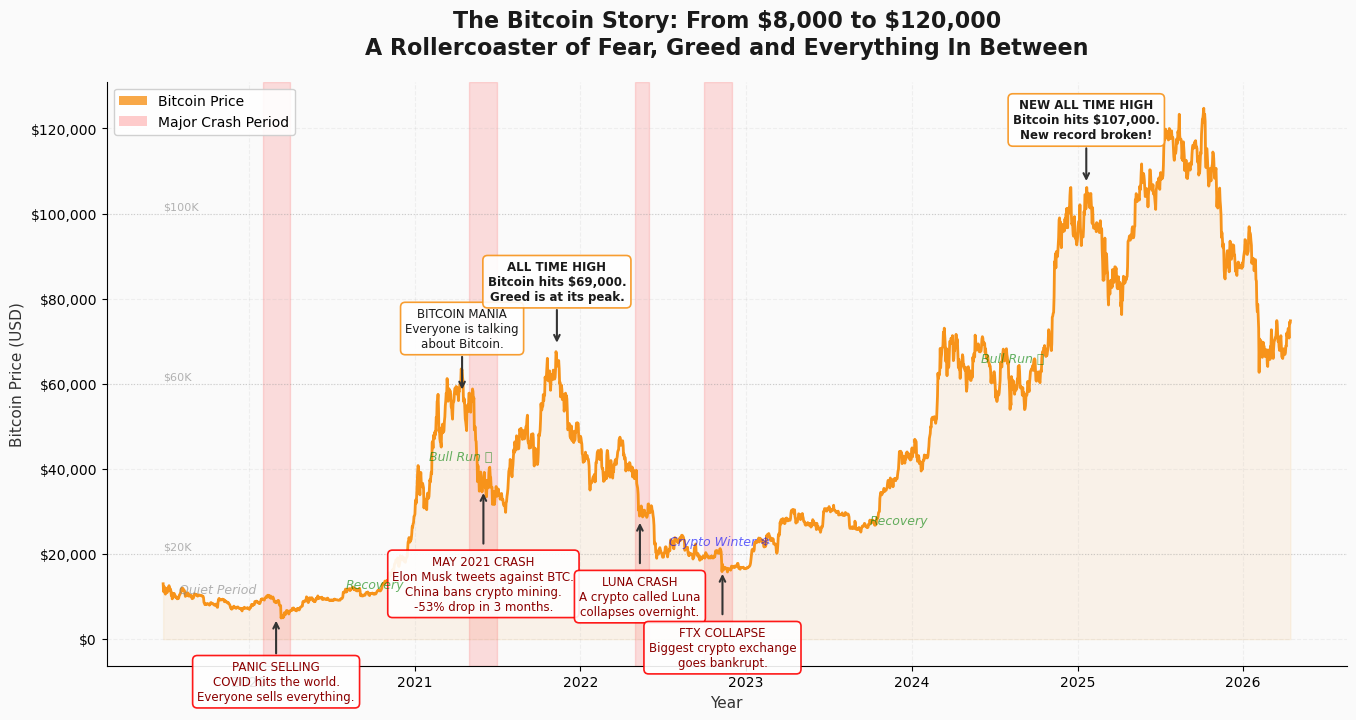

Plot 1 Final done!


In [11]:
# ================================================
# PLOT 1 — Bitcoin Price (Final Version)
# ================================================

fig, ax = plt.subplots(figsize=(16, 8))

fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

ax.plot(df.index,
        df['close'].values,
        color='#F7931A',
        linewidth=2,
        label='Bitcoin Price',
        zorder=3)

ax.fill_between(df.index,
                df['close'].values,
                alpha=0.08,
                color='#F7931A')

# Crash zones
crashes = [
    (pd.Timestamp('2020-02-01'), pd.Timestamp('2020-04-01')),
    (pd.Timestamp('2021-05-01'), pd.Timestamp('2021-07-01')),
    (pd.Timestamp('2022-05-01'), pd.Timestamp('2022-06-01')),
    (pd.Timestamp('2022-10-01'), pd.Timestamp('2022-12-01')),
]

for start, end in crashes:
    ax.axvspan(start, end, alpha=0.12, color='red', zorder=1)

# ── STORY ANNOTATIONS ──────────────────────────
stories = [
    (pd.Timestamp('2020-03-01'),
     5000,
     'PANIC SELLING',
     'COVID hits the world.\nEveryone sells everything.',
     -15000),

    (pd.Timestamp('2021-04-15'),
     58000,
     'BITCOIN MANIA',
     'Everyone is talking\nabout Bitcoin.',
     15000),

    (pd.Timestamp('2021-11-10'),
     69000,
     'ALL TIME HIGH',
     'Bitcoin hits $69,000.\nGreed is at its peak.',
     15000),

    # ── ADDED MAY 2021 CRASH ──
    (pd.Timestamp('2021-06-01'),
     35000,
     'MAY 2021 CRASH',
     'Elon Musk tweets against BTC.\nChina bans crypto mining.\n-53% drop in 3 months.',
     -22000),

    (pd.Timestamp('2022-05-12'),
     28000,
     'LUNA CRASH',
     'A crypto called Luna\ncollapses overnight.',
     -18000),

    (pd.Timestamp('2022-11-10'),
     16000,
     'FTX COLLAPSE',
     'Biggest crypto exchange\ngoes bankrupt.',
     -18000),

    (pd.Timestamp('2025-01-20'),
     107000,
     'NEW ALL TIME HIGH',
     'Bitcoin hits $107,000.\nNew record broken!',
     15000),
]

for date, price, title, desc, y_offset in stories:
    ax.annotate('',
                xy=(date, price),
                xytext=(date, price + y_offset * 0.6),
                arrowprops=dict(
                    arrowstyle='->',
                    color='#333333',
                    lw=1.5))

    ax.text(date, price + y_offset,
            f'{title}\n{desc}',
            fontsize=8.5,
            ha='center',
            va='center',
            fontweight='bold' if 'HIGH' in title else 'normal',
            color='darkred' if any(x in title for x in
                  ['PANIC', 'CRASH', 'COLLAPSE']) else '#1a1a1a',
            bbox=dict(
                boxstyle='round,pad=0.4',
                facecolor='white',
                edgecolor='red' if any(x in title for x in
                          ['PANIC', 'CRASH', 'COLLAPSE']) else '#F7931A',
                alpha=0.9,
                linewidth=1.2))

# Phase labels
phases = [
    (pd.Timestamp('2019-08-01'), 11000, 'Quiet Period', 'gray'),
    (pd.Timestamp('2020-08-01'), 12000, 'Recovery', 'green'),
    (pd.Timestamp('2021-02-01'), 42000, 'Bull Run 🚀', 'green'),
    (pd.Timestamp('2022-07-15'), 22000, 'Crypto Winter ❄️', 'blue'),
    (pd.Timestamp('2023-10-01'), 27000, 'Recovery', 'green'),
    (pd.Timestamp('2024-06-01'), 65000, 'Bull Run 🚀', 'green'),
]

for date, y, label, color in phases:
    ax.text(date, y, label,
            fontsize=9,
            color=color,
            alpha=0.6,
            style='italic')

# Price reference lines
for price, label in [(20000, '$20K'), (60000, '$60K'), (100000, '$100K')]:
    ax.axhline(y=price,
               color='gray',
               linestyle=':',
               alpha=0.3,
               linewidth=0.8)
    ax.text(df.index.min(),
            price + 1000,
            label,
            fontsize=8,
            color='gray',
            alpha=0.6)

# ── FIXED TITLE — much bolder and bigger ──────
ax.set_title('The Bitcoin Story: From \$8,000 to \$120,000\nA Rollercoaster of Fear, Greed and Everything In Between',
             fontsize=16,
             fontweight='bold',
             pad=20,
             color='#1a1a1a')

ax.set_xlabel('Year', fontsize=11, color='#333333')
ax.set_ylabel('Bitcoin Price (USD)', fontsize=11, color='#333333')
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
ax.grid(True, alpha=0.15, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#F7931A', alpha=0.8, label='Bitcoin Price'),
    Patch(facecolor='red',     alpha=0.2, label='Major Crash Period'),
]
ax.legend(handles=legend_elements,
          loc='upper left',
          fontsize=10,
          framealpha=0.9)

plt.subplots_adjust(bottom=0.15)
plt.savefig('plot1_btc_price_final.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 1 Final done!")

## 4. Exploratory Data Analysis

We created 5 visualizations to understand Bitcoin's price behavior 
and its relationship with market sentiment.

### Plot 1 — Bitcoin Price History (2019-2026)
Bitcoin grew from $8,000 to $120,000 over 6 years. Four major crashes 
are clearly visible — COVID (2020), May 2021, Luna Collapse and FTX 
Collapse (2022). Each crash was followed by recovery and new all time highs.

### Plot 2 — Fear & Greed Index
Market emotion swings dramatically over time. Extreme Greed (75+) 
appeared during bull runs (score 95 in 2021, score 90 in 2025). 
Extreme Fear appeared during crashes (score 8 during COVID, 
score 6-10 during Crypto Winter 2022).

### Plot 3 — Bitcoin Price vs Fear & Greed (Combined)
Most important finding — Extreme Greed preceded every major crash 
in our dataset. Green dotted lines mark greed peaks — red crash 
zones consistently follow shortly after.

### Plot 4 — Daily Returns Analysis
Bitcoin is positive only 50.3% of days — barely above a coin flip. 
Extreme moves (>±5%) occur on 9.9% of all days. Kurtosis of 10.34 
confirms fat tails — extreme events happen far more frequently than 
a normal distribution would predict.

### Plot 5 — Correlation Analysis
No single feature strongly predicts next day returns — Fear & Greed 
has the highest positive correlation (0.033). This weak predictability 
justifies our machine learning approach.

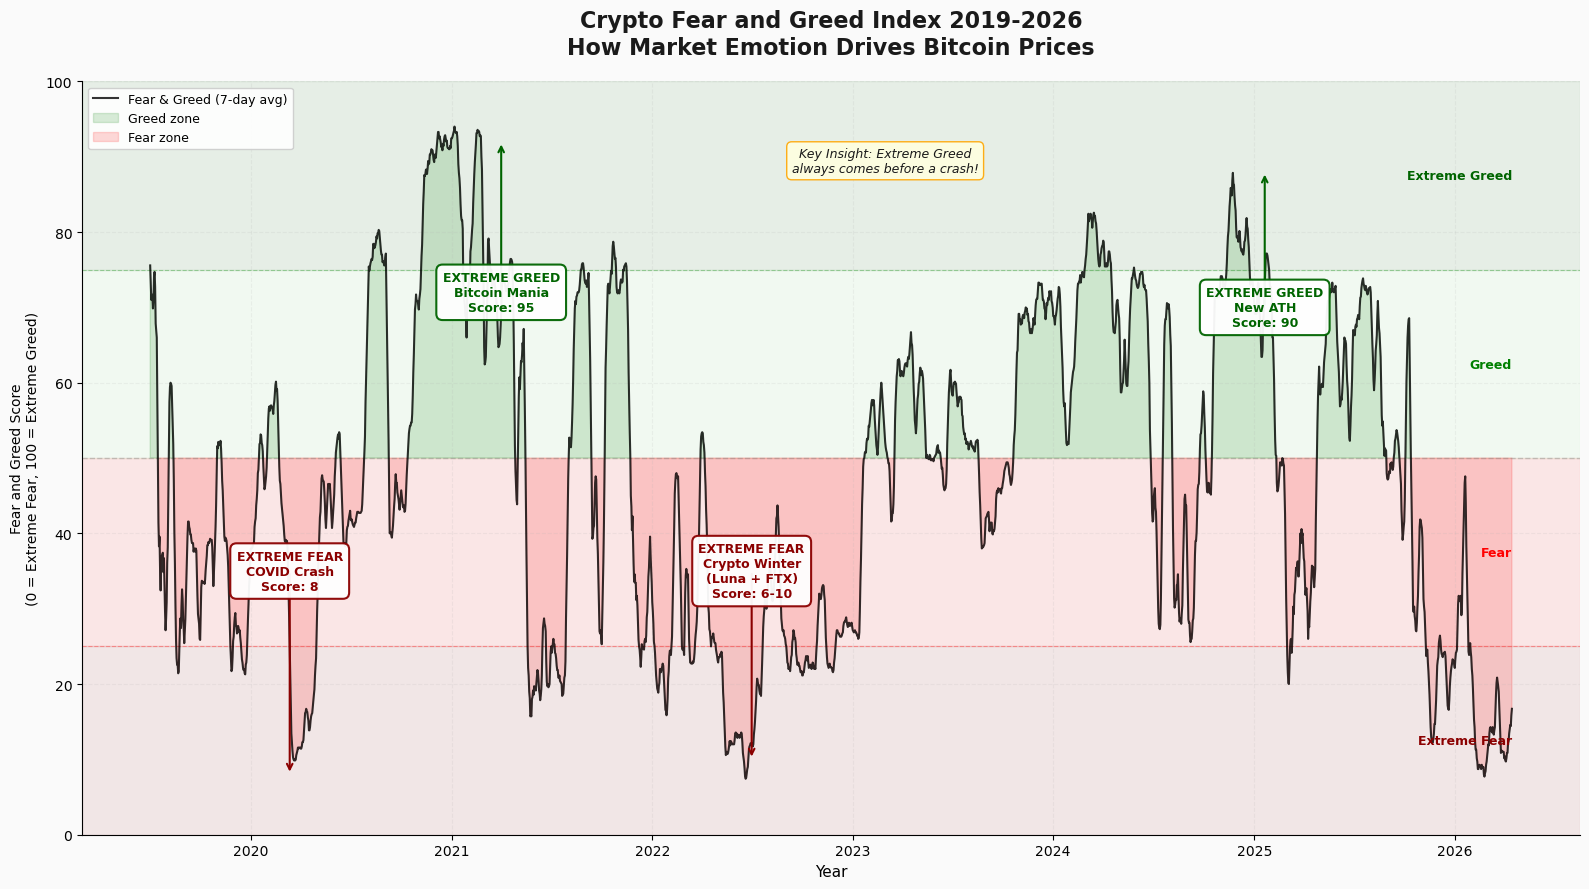

Plot 2 Final done!


In [12]:
# ================================================
# PLOT 2 — Fear & Greed Index (Simplified Final)
# ================================================

fig, ax = plt.subplots(figsize=(16, 9))

fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

# ── ZONE BACKGROUNDS ──────────────────────────
ax.axhspan(0,  25, alpha=0.08, color='darkred')
ax.axhspan(25, 50, alpha=0.08, color='red')
ax.axhspan(50, 75, alpha=0.08, color='lightgreen')
ax.axhspan(75, 100, alpha=0.08, color='darkgreen')

# ── SMOOTH LINE ───────────────────────────────
fg_smooth = pd.Series(df['fear_greed'].values,
                       index=df.index).rolling(7).mean()

ax.plot(df.index,
        fg_smooth.values,
        color='black',
        linewidth=1.5,
        alpha=0.8,
        zorder=3,
        label='Fear & Greed (7-day avg)')

# ── FILL ──────────────────────────────────────
ax.fill_between(df.index,
                fg_smooth.values, 50,
                where=fg_smooth.values >= 50,
                color='green', alpha=0.15,
                label='Greed zone')

ax.fill_between(df.index,
                fg_smooth.values, 50,
                where=fg_smooth.values < 50,
                color='red', alpha=0.15,
                label='Fear zone')

# ── REFERENCE LINES ───────────────────────────
ax.axhline(y=25, color='red',   linestyle='--', alpha=0.3, linewidth=0.8)
ax.axhline(y=50, color='gray',  linestyle='--', alpha=0.4, linewidth=1)
ax.axhline(y=75, color='green', linestyle='--', alpha=0.3, linewidth=0.8)

# ── SIMPLIFIED ANNOTATIONS ────────────────────
# Only 4 events — well spaced, no overlap
events = [
    # (date, score, label, text_y, color)
    (pd.Timestamp('2020-03-12'),  8,
     'EXTREME FEAR\nCOVID Crash\nScore: 8',
     35, 'darkred'),

    (pd.Timestamp('2021-04-01'), 92,
     'EXTREME GREED\nBitcoin Mania\nScore: 95',
     72, 'darkgreen'),

    (pd.Timestamp('2022-07-01'), 10,
     'EXTREME FEAR\nCrypto Winter\n(Luna + FTX)\nScore: 6-10',
     35, 'darkred'),

    (pd.Timestamp('2025-01-20'), 88,
     'EXTREME GREED\nNew ATH\nScore: 90',
     70, 'darkgreen'),
]

for date, score, label, text_y, color in events:
    # Draw arrow from text to actual score
    ax.annotate('',
                xy=(date, score),
                xytext=(date, text_y),
                arrowprops=dict(
                    arrowstyle='->',
                    color=color,
                    lw=1.5))

    ax.text(date, text_y,
            label,
            fontsize=9,
            ha='center',
            va='center',
            color=color,
            fontweight='bold',
            bbox=dict(
                boxstyle='round,pad=0.5',
                facecolor='white',
                edgecolor=color,
                alpha=0.95,
                linewidth=1.5))

# ── ZONE LABELS ON RIGHT ──────────────────────
ax.text(df.index.max(), 12,  'Extreme Fear',
        fontsize=9, color='darkred',   ha='right', fontweight='bold')
ax.text(df.index.max(), 37,  'Fear',
        fontsize=9, color='red',       ha='right', fontweight='bold')
ax.text(df.index.max(), 62,  'Greed',
        fontsize=9, color='green',     ha='right', fontweight='bold')
ax.text(df.index.max(), 87,  'Extreme Greed',
        fontsize=9, color='darkgreen', ha='right', fontweight='bold')

# ── KEY INSIGHT BOX ───────────────────────────
ax.text(pd.Timestamp('2023-03-01'), 88,
        'Key Insight: Extreme Greed\nalways comes before a crash!',
        fontsize=9,
        color='#1a1a1a',
        style='italic',
        ha='center',
        bbox=dict(boxstyle='round,pad=0.4',
                 facecolor='lightyellow',
                 edgecolor='orange',
                 alpha=0.9))

# ── FORMATTING ────────────────────────────────
ax.set_title('Crypto Fear and Greed Index 2019-2026\n'
             'How Market Emotion Drives Bitcoin Prices',
             fontsize=16,
             fontweight='bold',
             pad=20,
             color='#1a1a1a')

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Fear and Greed Score\n(0 = Extreme Fear, 100 = Extreme Greed)',
              fontsize=10)
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.15, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='upper left', fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig('plot2_fear_greed.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 2 Final done!")

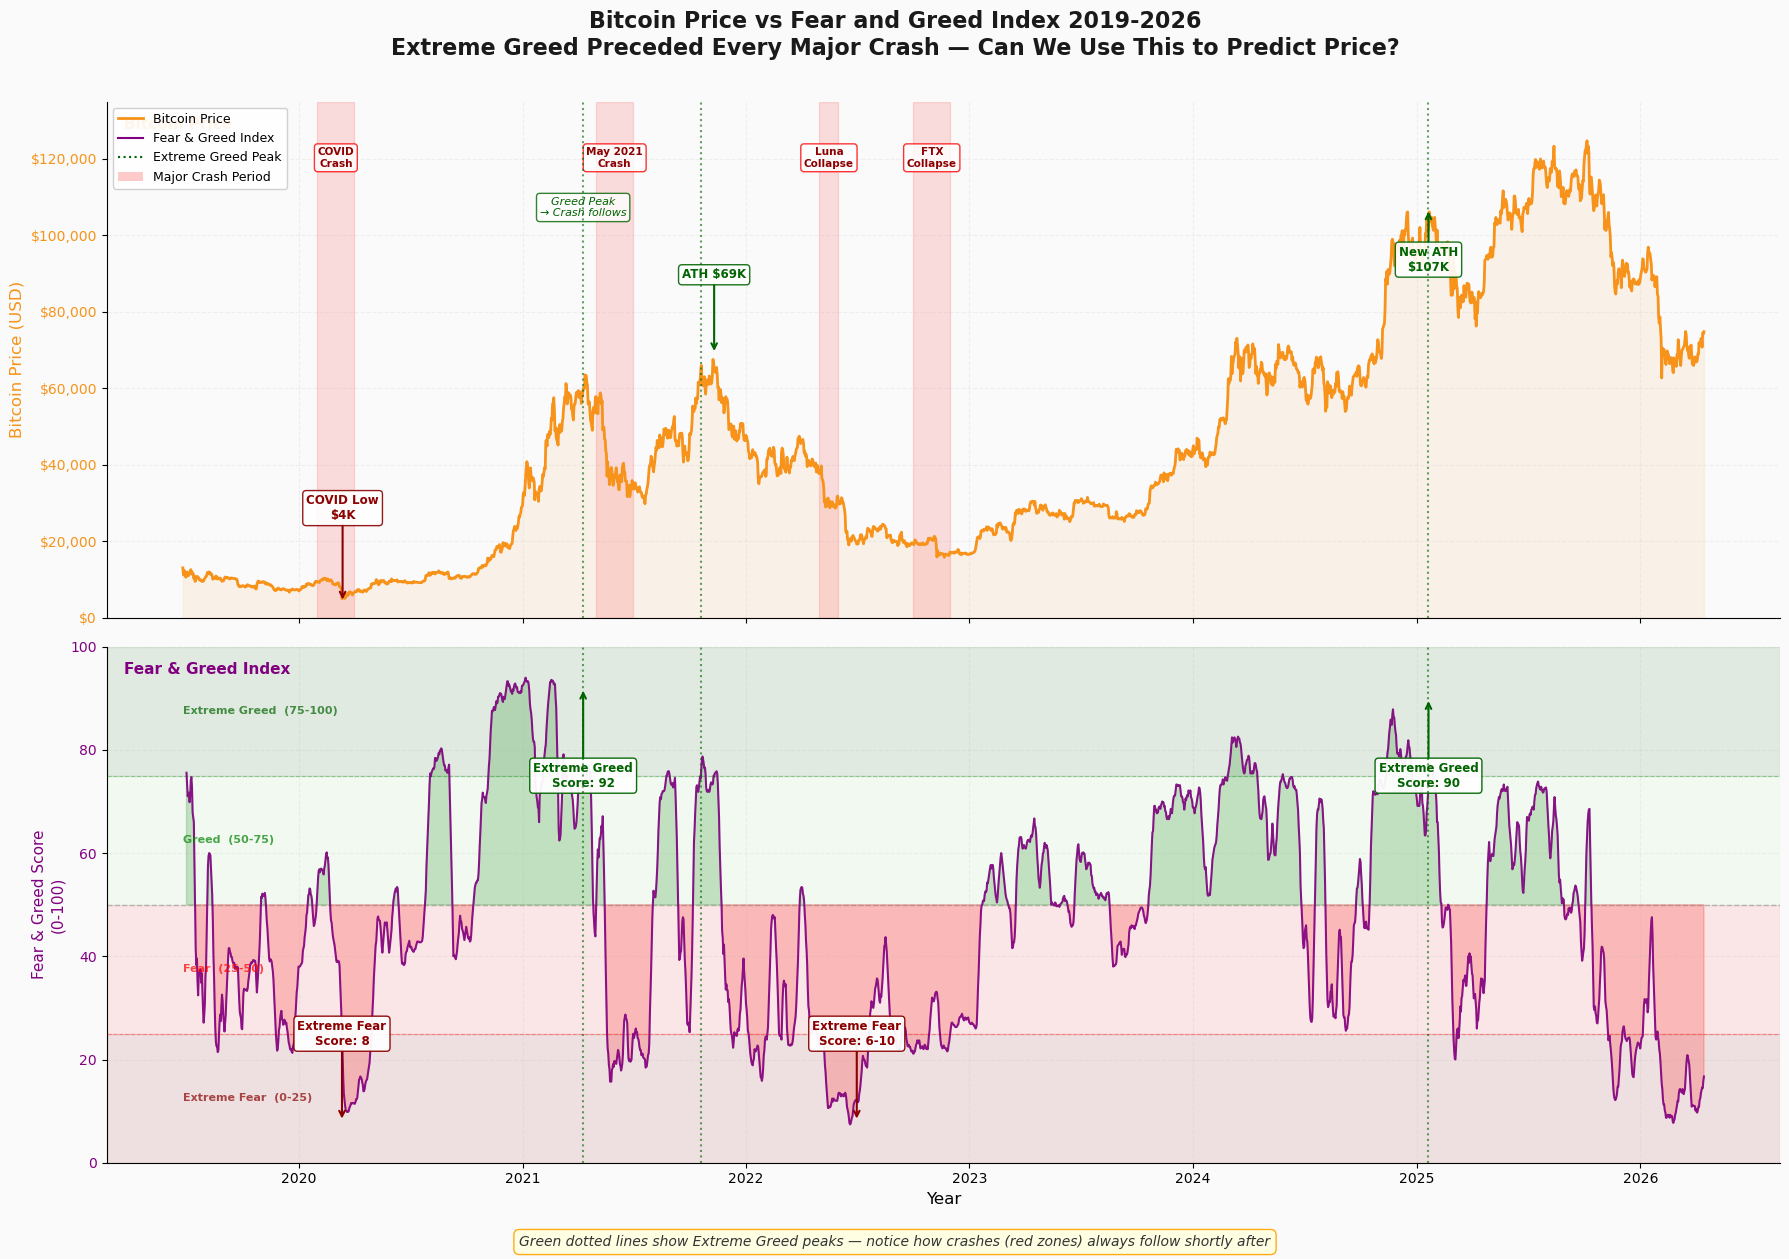

Plot 3 Final done!


In [13]:
# ================================================
# PLOT 3 — Complete Redesign (Final Version)
# ================================================

fig, (ax1, ax2) = plt.subplots(2, 1,
                                figsize=(18, 12),
                                sharex=True,
                                gridspec_kw={'height_ratios': [1, 1]})  # equal size panels

fig.patch.set_facecolor('#FAFAFA')
ax1.set_facecolor('#FAFAFA')
ax2.set_facecolor('#FAFAFA')

# ── SMOOTH FEAR & GREED ───────────────────────
fg_smooth = pd.Series(df['fear_greed'].values,
                       index=df.index).rolling(7).mean()

# ══════════════════════════════════════════════
# TOP PANEL — Bitcoin Price
# ══════════════════════════════════════════════
ax1.plot(df.index,
         df['close'].values,
         color='#F7931A',
         linewidth=2,
         label='BTC Price',
         zorder=3)

ax1.fill_between(df.index,
                 df['close'].values,
                 alpha=0.08,
                 color='#F7931A')

# Crash zones TOP panel only
crashes = [
    (pd.Timestamp('2020-02-01'), pd.Timestamp('2020-04-01'), 'COVID\nCrash'),
    (pd.Timestamp('2021-05-01'), pd.Timestamp('2021-07-01'), 'May 2021\nCrash'),
    (pd.Timestamp('2022-05-01'), pd.Timestamp('2022-06-01'), 'Luna\nCollapse'),
    (pd.Timestamp('2022-10-01'), pd.Timestamp('2022-12-01'), 'FTX\nCollapse'),
]

for start, end, label in crashes:
    ax1.axvspan(start, end, alpha=0.12, color='red', zorder=1)
    mid = start + (end - start) / 2
    ax1.text(mid, 118000, label,
             fontsize=7.5, ha='center', color='darkred',
             fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.3',
                      facecolor='white',
                      edgecolor='red',
                      alpha=0.8))

# Price annotations
price_annotations = [
    (pd.Timestamp('2020-03-13'), 4000,  'COVID Low\n$4K',    25000, 'darkred'),
    (pd.Timestamp('2021-11-10'), 69000, 'ATH $69K',          88000, 'darkgreen'),
    (pd.Timestamp('2025-01-20'), 107000,'New ATH\n$107K',    90000, 'darkgreen'),
]

for date, price, label, text_y, color in price_annotations:
    ax1.annotate('',
                 xy=(date, price),
                 xytext=(date, text_y),
                 arrowprops=dict(arrowstyle='->',
                                color=color, lw=1.5))
    ax1.text(date, text_y, label,
             fontsize=8.5, ha='center', va='bottom',
             color=color, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.3',
                      facecolor='white',
                      edgecolor=color,
                      alpha=0.9))

ax1.set_ylabel('Bitcoin Price (USD)', fontsize=12, color='#F7931A')
ax1.tick_params(axis='y', labelcolor='#F7931A')
ax1.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
ax1.grid(True, alpha=0.15, linestyle='--')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_ylim(0, 135000)

# Panel label
ax1.text(0.01, 0.97, 'Bitcoin Price',
         transform=ax1.transAxes,
         fontsize=11, fontweight='bold',
         color='#F7931A', va='top')

# ══════════════════════════════════════════════
# VERTICAL DOTTED LINES — connecting greed peaks
# to crashes (THE KEY VISUAL CONNECTION)
# ══════════════════════════════════════════════
greed_peaks = [
    pd.Timestamp('2021-04-10'),   # greed peak before may crash
    pd.Timestamp('2021-10-20'),   # greed peak before nov-dec crash
    pd.Timestamp('2025-01-20'),   # greed peak before 2025 pullback
]

for peak in greed_peaks:
    # Draw vertical line across BOTH panels
    ax1.axvline(x=peak, color='darkgreen',
                linestyle=':', linewidth=1.5, alpha=0.6, zorder=4)
    ax2.axvline(x=peak, color='darkgreen',
                linestyle=':', linewidth=1.5, alpha=0.6, zorder=4)

# Label one of them to explain
ax1.text(pd.Timestamp('2021-04-10'), 105000,
         'Greed Peak\n→ Crash follows',
         fontsize=8, color='darkgreen',
         ha='center', style='italic',
         bbox=dict(boxstyle='round,pad=0.3',
                  facecolor='white',
                  edgecolor='darkgreen',
                  alpha=0.8))

# ══════════════════════════════════════════════
# BOTTOM PANEL — Fear & Greed
# ══════════════════════════════════════════════

# Zone backgrounds
ax2.axhspan(0,  25, alpha=0.1,  color='darkred',   label='Extreme Fear')
ax2.axhspan(25, 50, alpha=0.08, color='red',        label='Fear')
ax2.axhspan(50, 75, alpha=0.08, color='lightgreen', label='Greed')
ax2.axhspan(75, 100, alpha=0.1, color='darkgreen',  label='Extreme Greed')

# Plot line
ax2.plot(df.index,
         fg_smooth.values,
         color='purple',
         linewidth=1.5,
         alpha=0.9,
         zorder=3)

# Clean fill
ax2.fill_between(df.index, fg_smooth.values, 50,
                 where=fg_smooth.values >= 50,
                 color='green', alpha=0.2)
ax2.fill_between(df.index, fg_smooth.values, 50,
                 where=fg_smooth.values < 50,
                 color='red', alpha=0.2)

# Reference lines
ax2.axhline(y=25, color='red',   linestyle='--', alpha=0.3, linewidth=0.8)
ax2.axhline(y=50, color='gray',  linestyle='--', alpha=0.5, linewidth=1)
ax2.axhline(y=75, color='green', linestyle='--', alpha=0.3, linewidth=0.8)

# Fear & Greed annotations
fg_annotations = [
    (pd.Timestamp('2020-03-12'),  8,  'Extreme Fear\nScore: 8',  25, 'darkred'),
    (pd.Timestamp('2021-04-10'), 92,  'Extreme Greed\nScore: 92', 75, 'darkgreen'),
    (pd.Timestamp('2022-07-01'),  8,  'Extreme Fear\nScore: 6-10', 25, 'darkred'),
    (pd.Timestamp('2025-01-20'), 90,  'Extreme Greed\nScore: 90', 75, 'darkgreen'),
]

for date, score, label, text_y, color in fg_annotations:
    ax2.annotate('',
                 xy=(date, score),
                 xytext=(date, text_y),
                 arrowprops=dict(arrowstyle='->',
                                color=color, lw=1.5))
    ax2.text(date, text_y, label,
             fontsize=8.5, ha='center', va='center',
             color=color, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.3',
                      facecolor='white',
                      edgecolor=color,
                      alpha=0.95))

# Zone labels — properly positioned
ax2.text(df.index.min(), 12,  'Extreme Fear  (0-25)',
         fontsize=8, color='darkred',   fontweight='bold', alpha=0.7)
ax2.text(df.index.min(), 37,  'Fear  (25-50)',
         fontsize=8, color='red',       fontweight='bold', alpha=0.7)
ax2.text(df.index.min(), 62,  'Greed  (50-75)',
         fontsize=8, color='green',     fontweight='bold', alpha=0.7)
ax2.text(df.index.min(), 87,  'Extreme Greed  (75-100)',
         fontsize=8, color='darkgreen', fontweight='bold', alpha=0.7)

ax2.set_ylabel('Fear & Greed Score\n(0-100)', fontsize=11, color='purple')
ax2.tick_params(axis='y', labelcolor='purple')
ax2.set_ylim(0, 100)
ax2.set_xlabel('Year', fontsize=12)
ax2.grid(True, alpha=0.15, linestyle='--')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Panel label
ax2.text(0.01, 0.97, 'Fear & Greed Index',
         transform=ax2.transAxes,
         fontsize=11, fontweight='bold',
         color='purple', va='top')

# ── MAIN TITLE ────────────────────────────────
fig.suptitle('Bitcoin Price vs Fear and Greed Index 2019-2026\n'
             'Extreme Greed Preceded Every Major Crash — Can We Use This to Predict Price?',
             fontsize=16,
             fontweight='bold',
             color='#1a1a1a',
             y=1.01)

# ── BOTTOM INSIGHT ────────────────────────────
fig.text(0.5, -0.02,
         'Green dotted lines show Extreme Greed peaks — notice how crashes (red zones) always follow shortly after',
         ha='center', fontsize=10,
         style='italic', color='#333333',
         bbox=dict(boxstyle='round,pad=0.4',
                  facecolor='lightyellow',
                  edgecolor='orange',
                  alpha=0.9))

# ── COMBINED LEGEND ───────────────────────────
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

legend_elements = [
    Line2D([0], [0], color='#F7931A', linewidth=2,   label='Bitcoin Price'),
    Line2D([0], [0], color='purple',  linewidth=1.5,  label='Fear & Greed Index'),
    Line2D([0], [0], color='darkgreen', linewidth=1.5,
           linestyle=':', label='Extreme Greed Peak'),
    Patch(facecolor='red',   alpha=0.2, label='Major Crash Period'),
]

ax1.legend(handles=legend_elements,
           loc='upper left',
           fontsize=9,
           framealpha=0.9)

plt.tight_layout()
plt.savefig('plot3_combined_final.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot 3 Final done!")

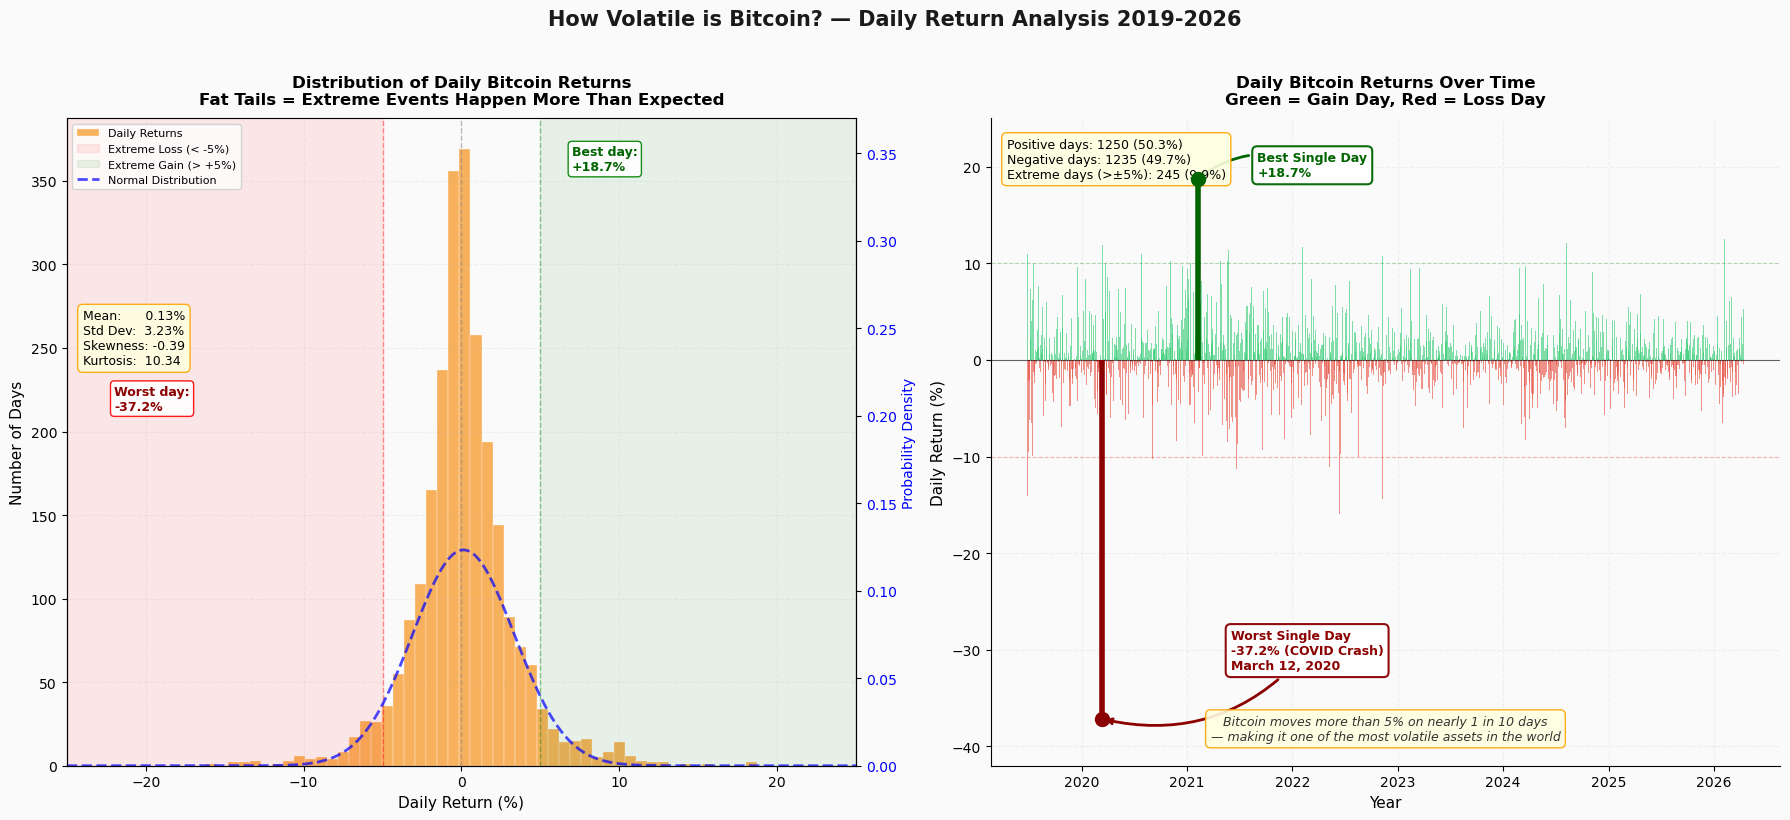

Plot 4 Final done!


In [40]:
# ================================================
# PLOT 4 — Daily Returns (Fixed Version)
# ================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

fig.patch.set_facecolor('#FAFAFA')
axes[0].set_facecolor('#FAFAFA')
axes[1].set_facecolor('#FAFAFA')

from scipy import stats
import numpy as np

returns_pct = df['daily_return'].values * 100

# ══════════════════════════════════════════════
# LEFT CHART — Distribution
# ══════════════════════════════════════════════
ax1 = axes[0]

ax1.hist(returns_pct,
         bins=80,
         color='#F7931A',
         alpha=0.7,
         edgecolor='white',
         linewidth=0.3,
         label='Daily Returns')

# Normal curve
mu  = returns_pct.mean()
std = returns_pct.std()

# FIX 3 — zoomed x axis -25 to +25
x = np.linspace(-25, 25, 300)
normal_curve = stats.norm.pdf(x, mu, std)

ax1_twin = ax1.twinx()
ax1_twin.plot(x, normal_curve,
              color='blue',
              linewidth=2,
              linestyle='--',
              alpha=0.7,
              label='Normal Distribution')
ax1_twin.set_ylabel('Probability Density',
                     fontsize=10, color='blue')
ax1_twin.tick_params(axis='y', labelcolor='blue')
ax1_twin.set_ylim(0, normal_curve.max() * 3)

# Shaded zones
ax1.axvspan(-25, -5, alpha=0.08, color='red',   label='Extreme Loss (< -5%)')
ax1.axvspan(5,   25, alpha=0.08, color='green', label='Extreme Gain (> +5%)')

# Reference lines
ax1.axvline(x=0,  color='gray',  linestyle='--', alpha=0.5, linewidth=1)
ax1.axvline(x=-5, color='red',   linestyle='--', alpha=0.4, linewidth=1)
ax1.axvline(x=5,  color='green', linestyle='--', alpha=0.4, linewidth=1)

# Worst/Best day annotations
ax1.text(-22, ax1.get_ylim()[1] * 0.55,
         f'Worst day:\n{returns_pct.min():.1f}%',
         fontsize=9, color='darkred', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.3',
                  facecolor='white',
                  edgecolor='red', alpha=0.9))
ax1.text(7, ax1.get_ylim()[1] * 0.92,
         f'Best day:\n+{returns_pct.max():.1f}%',
         fontsize=9, color='darkgreen', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.3',
                  facecolor='white',
                  edgecolor='green', alpha=0.9))

# Stats box
ax1.text(0.02, 0.62,
         f'Mean:      {mu:.2f}%\n'
         f'Std Dev:  {std:.2f}%\n'
         f'Skewness: {stats.skew(returns_pct):.2f}\n'
         f'Kurtosis:  {stats.kurtosis(returns_pct):.2f}',
         transform=ax1.transAxes,
         fontsize=9,
         bbox=dict(boxstyle='round,pad=0.4',
                  facecolor='lightyellow',
                  edgecolor='orange', alpha=0.9))

# FIX 3 — zoom x axis
ax1.set_xlim(-25, 25)

ax1.set_title('Distribution of Daily Bitcoin Returns\n'
              'Fat Tails = Extreme Events Happen More Than Expected',
              fontsize=12, fontweight='bold', pad=10)
ax1.set_xlabel('Daily Return (%)', fontsize=11)
ax1.set_ylabel('Number of Days', fontsize=11)
ax1.grid(True, alpha=0.15, linestyle='--')
ax1.spines['top'].set_visible(False)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           fontsize=8, loc='upper left')

# ══════════════════════════════════════════════
# RIGHT CHART — Returns Over Time
# ══════════════════════════════════════════════
ax2 = axes[1]
ax2.set_facecolor('#FAFAFA')

# Colors for each bar
colors = ['#2ecc71' if r > 0 else '#e74c3c'
          for r in df['daily_return'].values]

# Plot all bars
ax2.bar(df.index,
        returns_pct,
        color=colors,
        alpha=0.6,
        width=2)

# Set y axis range first
ax2.set_ylim(-42, 25)

# Find worst and best days
worst_idx = df['daily_return'].idxmin()
worst_val = df['daily_return'].min() * 100
best_idx  = df['daily_return'].idxmax()
best_val  = df['daily_return'].max() * 100

# ── WORST DAY ─────────────────────────────────
# Draw thick visible line from 0 to -37.2%
ax2.vlines(x=worst_idx,
           ymin=worst_val,
           ymax=0,
           color='darkred',
           linewidth=4,
           zorder=5,
           label='_nolegend_')

# Dot at the bottom
ax2.scatter([worst_idx], [worst_val],
            color='darkred',
            s=100,
            zorder=6)

# Annotation with curved arrow
ax2.annotate('Worst Single Day\n-37.2% (COVID Crash)\nMarch 12, 2020',
             xy=(worst_idx, worst_val),
             xytext=(pd.Timestamp('2021-06-01'), -32),
             fontsize=9,
             color='darkred',
             fontweight='bold',
             ha='left',
             bbox=dict(boxstyle='round,pad=0.4',
                      facecolor='white',
                      edgecolor='darkred',
                      linewidth=1.5,
                      alpha=0.95),
             arrowprops=dict(arrowstyle='->',
                            color='darkred',
                            lw=2,
                            connectionstyle='arc3,rad=-0.3'))

# ── BEST DAY ──────────────────────────────────
# Draw thick visible line from 0 to +18.7%
ax2.vlines(x=best_idx,
           ymin=0,
           ymax=best_val,
           color='darkgreen',
           linewidth=4,
           zorder=5,
           label='_nolegend_')

# Dot at the top
ax2.scatter([best_idx], [best_val],
            color='darkgreen',
            s=100,
            zorder=6)

# Annotation with curved arrow
ax2.annotate(f'Best Single Day\n+{best_val:.1f}%',
             xy=(best_idx, best_val),
             xytext=(pd.Timestamp('2021-09-01'), 19),
             fontsize=9,
             color='darkgreen',
             fontweight='bold',
             ha='left',
             bbox=dict(boxstyle='round,pad=0.4',
                      facecolor='white',
                      edgecolor='darkgreen',
                      linewidth=1.5,
                      alpha=0.95),
             arrowprops=dict(arrowstyle='->',
                            color='darkgreen',
                            lw=2,
                            connectionstyle='arc3,rad=0.3'))

# ── REFERENCE LINES ───────────────────────────
ax2.axhline(y=0,   color='black', linewidth=0.8, alpha=0.6)
ax2.axhline(y=10,  color='green', linestyle='--', alpha=0.25, linewidth=0.8)
ax2.axhline(y=-10, color='red',   linestyle='--', alpha=0.25, linewidth=0.8)

# ── STATS BOX ─────────────────────────────────
positive_days = (df['daily_return'] > 0).sum()
negative_days = (df['daily_return'] < 0).sum()
extreme_days  = (df['daily_return'].abs() > 0.05).sum()

ax2.text(0.02, 0.97,
         f'Positive days: {positive_days} ({positive_days/len(df)*100:.1f}%)\n'
         f'Negative days: {negative_days} ({negative_days/len(df)*100:.1f}%)\n'
         f'Extreme days (>±5%): {extreme_days} ({extreme_days/len(df)*100:.1f}%)',
         transform=ax2.transAxes,
         fontsize=9, va='top',
         bbox=dict(boxstyle='round,pad=0.4',
                  facecolor='lightyellow',
                  edgecolor='orange', alpha=0.9))

# ── INSIGHT BOX ───────────────────────────────
ax2.text(0.5, 0.04,
         'Bitcoin moves more than 5% on nearly 1 in 10 days\n'
         '— making it one of the most volatile assets in the world',
         transform=ax2.transAxes,
         fontsize=9, ha='center',
         style='italic', color='#333333',
         bbox=dict(boxstyle='round,pad=0.4',
                  facecolor='lightyellow',
                  edgecolor='orange', alpha=0.9))

# ── FORMATTING ────────────────────────────────
ax2.set_title('Daily Bitcoin Returns Over Time\n'
              'Green = Gain Day, Red = Loss Day',
              fontsize=12, fontweight='bold', pad=10)
ax2.set_xlabel('Year', fontsize=11)
ax2.set_ylabel('Daily Return (%)', fontsize=11)
ax2.grid(True, alpha=0.15, linestyle='--')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# ── MAIN TITLE ────────────────────────────────
fig.suptitle('How Volatile is Bitcoin? — Daily Return Analysis 2019-2026',
             fontsize=15,
             fontweight='bold',
             color='#1a1a1a',
             y=1.02)

plt.tight_layout()
plt.savefig('plot4_returns_final.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 4 Final done!")

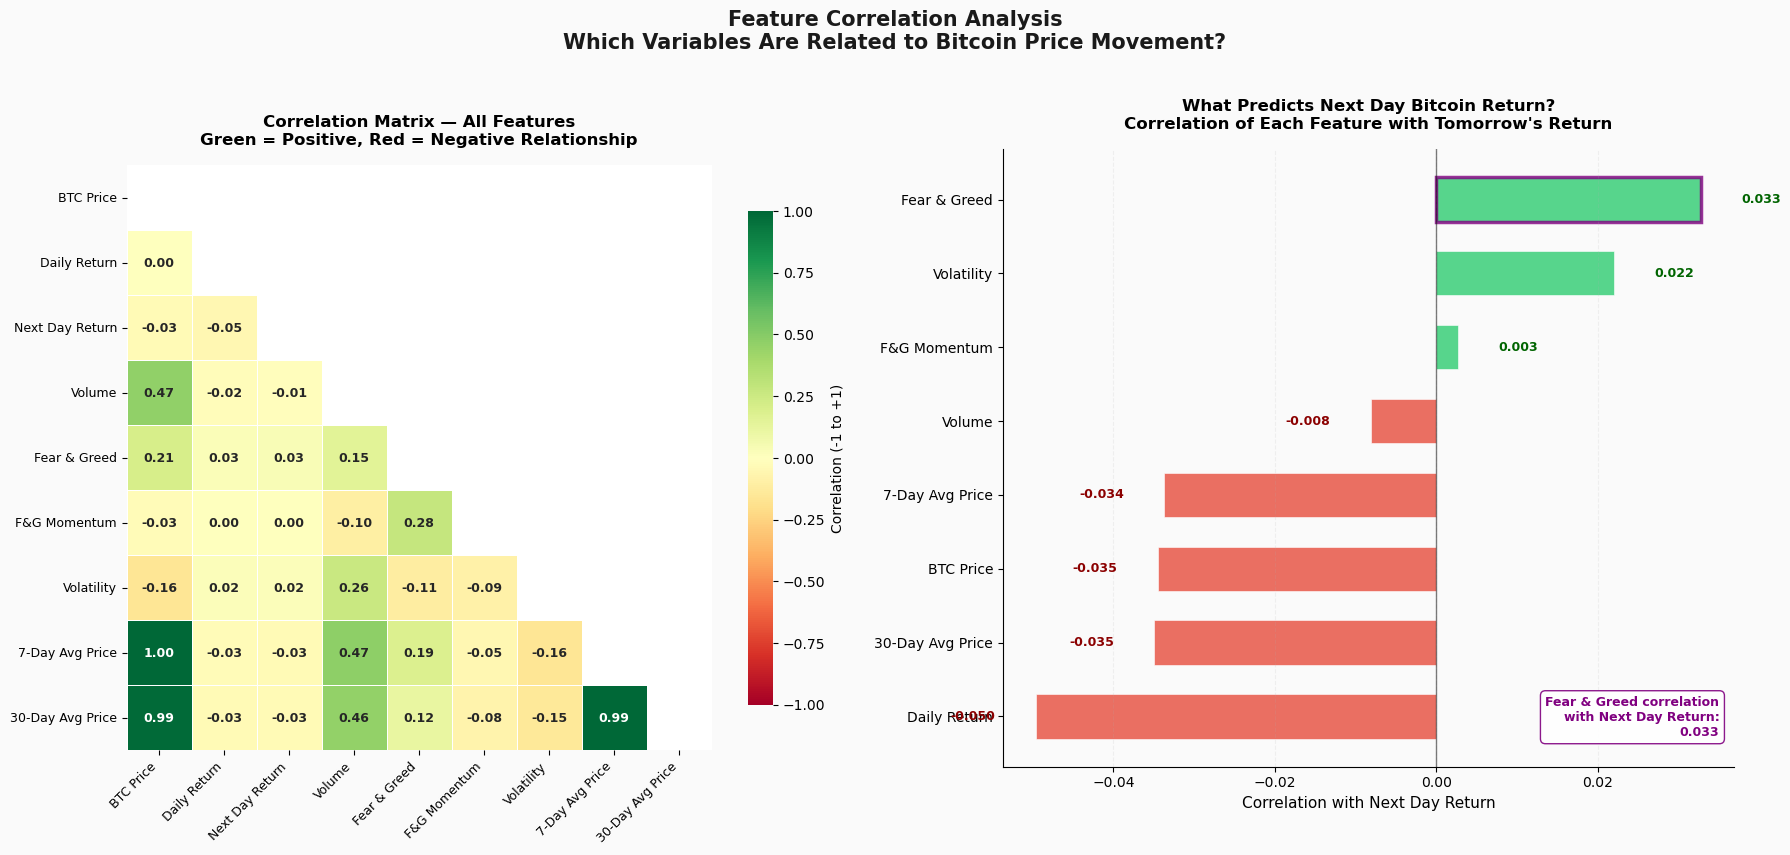

Plot 5 done!


In [50]:
# ================================================
# PLOT 5 — Correlation Heatmap
# ================================================
# WHY: Shows which variables are related to each other
# Most importantly — does Fear & Greed correlate
# with Bitcoin returns?
# This is the mathematical proof before modeling
# ================================================

import numpy as np

# ── FEATURE ENGINEERING FOR HEATMAP ──────────
# Create extra features to make heatmap richer

df_corr = df.copy()

# Rolling averages
df_corr['7day_MA']  = df_corr['close'].rolling(7).mean()
df_corr['30day_MA'] = df_corr['close'].rolling(30).mean()

# Volatility — rolling std of returns
df_corr['volatility'] = df_corr['daily_return'].rolling(7).std()

# Fear & Greed momentum — change over 7 days
df_corr['fg_momentum'] = df_corr['fear_greed'].diff(7)

# Next day return — our TARGET variable
df_corr['next_day_return'] = df_corr['daily_return'].shift(-1)

# Drop NaN rows
df_corr = df_corr.dropna()

# Select columns for correlation
corr_cols = {
    'close'           : 'BTC Price',
    'daily_return'    : 'Daily Return',
    'next_day_return' : 'Next Day Return',
    'volume'          : 'Volume',
    'fear_greed'      : 'Fear & Greed',
    'fg_momentum'     : 'F&G Momentum',
    'volatility'      : 'Volatility',
    '7day_MA'         : '7-Day Avg Price',
    '30day_MA'        : '30-Day Avg Price',
}

# Compute correlation matrix
corr_matrix = df_corr[list(corr_cols.keys())].corr()
corr_matrix.index   = list(corr_cols.values())
corr_matrix.columns = list(corr_cols.values())

# ── PLOT ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.patch.set_facecolor('#FAFAFA')

# ══════════════════════════════════════════════
# LEFT — Full Correlation Heatmap
# ══════════════════════════════════════════════
ax1 = axes[0]

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # hide upper triangle

sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            vmin=-1, vmax=1,
            linewidths=0.5,
            linecolor='white',
            annot_kws={'size': 9, 'weight': 'bold'},
            ax=ax1,
            square=True,
            cbar_kws={'shrink': 0.8,
                      'label': 'Correlation (-1 to +1)'})

ax1.set_title('Correlation Matrix — All Features\n'
              'Green = Positive, Red = Negative Relationship',
              fontsize=12, fontweight='bold', pad=15)

ax1.set_xticklabels(ax1.get_xticklabels(),
                     rotation=45, ha='right', fontsize=9)
ax1.set_yticklabels(ax1.get_yticklabels(),
                     rotation=0, fontsize=9)

# ══════════════════════════════════════════════
# RIGHT — Fear & Greed vs Key Variables Bar Chart
# ══════════════════════════════════════════════
ax2 = axes[1]
ax2.set_facecolor('#FAFAFA')

# Get correlations with next day return specifically
target_corr = corr_matrix['Next Day Return'].drop('Next Day Return')
target_corr = target_corr.sort_values(ascending=True)

# Color bars
bar_colors = ['#e74c3c' if v < 0 else '#2ecc71'
               for v in target_corr.values]

bars = ax2.barh(target_corr.index,
                target_corr.values,
                color=bar_colors,
                alpha=0.8,
                edgecolor='white',
                linewidth=0.5,
                height=0.6)

# Add value labels on bars
for bar, val in zip(bars, target_corr.values):
    ax2.text(val + (0.005 if val >= 0 else -0.005),
             bar.get_y() + bar.get_height()/2,
             f'{val:.3f}',
             va='center',
             ha='left' if val >= 0 else 'right',
             fontsize=9,
             fontweight='bold',
             color='darkgreen' if val >= 0 else 'darkred')

# Reference line
ax2.axvline(x=0, color='black', linewidth=1, alpha=0.5)

# Highlight Fear & Greed bar
fg_idx = list(target_corr.index).index('Fear & Greed')
bars[fg_idx].set_edgecolor('purple')
bars[fg_idx].set_linewidth(2.5)

# Insight annotation
fg_corr_val = target_corr['Fear & Greed']
ax2.text(0.98, 0.05,
         f'Fear & Greed correlation\nwith Next Day Return:\n{fg_corr_val:.3f}',
         transform=ax2.transAxes,
         fontsize=9,
         ha='right',
         color='purple',
         fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.4',
                  facecolor='white',
                  edgecolor='purple',
                  alpha=0.9))

ax2.set_title('What Predicts Next Day Bitcoin Return?\n'
              'Correlation of Each Feature with Tomorrow\'s Return',
              fontsize=12, fontweight='bold', pad=15)
ax2.set_xlabel('Correlation with Next Day Return', fontsize=11)
ax2.set_ylabel('')
ax2.grid(True, alpha=0.15, linestyle='--', axis='x')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# ── MAIN TITLE ────────────────────────────────
fig.suptitle('Feature Correlation Analysis\n'
             'Which Variables Are Related to Bitcoin Price Movement?',
             fontsize=15,
             fontweight='bold',
             color='#1a1a1a',
             y=1.02)

plt.tight_layout()
plt.savefig('plot5_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 5 done!")

## 5. Feature Engineering

We created 23 new features from raw data to enrich the dataset 
for machine learning modeling.

### Price Features
- `price_vs_7MA` — ratio of price to 7-day moving average
- `price_vs_30MA` — ratio of price to 30-day moving average

### Return Features
- `return_lag1/2/3/7` — lagged returns (captures mean reversion signal found in EDA)
- `return_7day/30day` — rolling period returns (captures momentum)

### Volatility Features
- `volatility_7day` — 7-day rolling standard deviation
- `volatility_30day` — 30-day rolling standard deviation

### Fear & Greed Features
- `fg_lag1/3/7` — lagged Fear & Greed scores
- `fg_momentum_7/14` — change in score over 7/14 days
- `fg_7day_avg/30day_avg` — rolling averages
- `is_extreme_fear` — binary flag: score ≤ 25
- `is_extreme_greed` — binary flag: score ≥ 75

### Technical Indicators
- `rsi_14` — Relative Strength Index (overbought/oversold signal)
- `macd/macd_signal/macd_hist` — momentum indicator
- `bb_position` — price position within Bollinger Bands
- `roc_5/10/20` — Rate of Change over 5, 10, 20 days

### Volume Features
- `volume_change` — daily change in trading volume
- `volume_vs_avg` — volume relative to 7-day average

### Target Variables
- **Regression:** `target_return` — next day return (continuous)
- **Classification:** `target_crash` — 1 if next day drop > 5%, else 0

### Crash Threshold Justification
We tested multiple thresholds and selected **-5%** because:
- Consistent with EDA finding that ±5% moves are genuinely extreme (top 9.9% of days)
- Provides enough crash examples (106 days) for model learning
- Meaningful threshold — Bitcoin's average daily volatility is 3.23%

### Train/Test Split
Chronological 80/20 split — random split avoided to prevent look-ahead bias:

| Split | Period | Rows |
|---|---|---|
| Training | Sep 2019 – Dec 2024 | 1,916 (80%) |
| Testing | Dec 2024 – Apr 2026 | 479 (20%) |

In [52]:
# ================================================
# SECTION 3 — FEATURE ENGINEERING
# ================================================
# WHY: Raw data alone isn't enough for ML models
# We create new features that capture:
# - Price momentum (moving averages)
# - Market volatility
# - Fear & Greed momentum
# - Lagged returns (mean reversion signal)
# ================================================

import numpy as np
from sklearn.preprocessing import StandardScaler

# Start fresh copy of df
df_model = df.copy()

# ── PRICE FEATURES ────────────────────────────

# Moving averages — smoothed price trends
df_model['7day_MA']  = df_model['close'].rolling(7).mean()
df_model['30day_MA'] = df_model['close'].rolling(30).mean()
df_model['90day_MA'] = df_model['close'].rolling(90).mean()

# Price vs moving average ratio
# Shows if price is above or below its trend
df_model['price_vs_7MA']  = df_model['close'] / df_model['7day_MA']
df_model['price_vs_30MA'] = df_model['close'] / df_model['30day_MA']

# ── RETURN FEATURES ───────────────────────────

# Lagged returns — captures mean reversion signal we found in Plot 5
df_model['return_lag1'] = df_model['daily_return'].shift(1)  # yesterday
df_model['return_lag2'] = df_model['daily_return'].shift(2)  # 2 days ago
df_model['return_lag3'] = df_model['daily_return'].shift(3)  # 3 days ago
df_model['return_lag7'] = df_model['daily_return'].shift(7)  # 1 week ago

# Rolling return — how much has BTC moved in last 7/30 days
df_model['return_7day']  = df_model['close'].pct_change(7)
df_model['return_30day'] = df_model['close'].pct_change(30)

# ── VOLATILITY FEATURES ───────────────────────

# Rolling volatility — captures risk level
# From Plot 4 we know volatility has predictive power (0.022)
df_model['volatility_7day']  = df_model['daily_return'].rolling(7).std()
df_model['volatility_30day'] = df_model['daily_return'].rolling(30).std()

# ── FEAR & GREED FEATURES ─────────────────────

# Lagged Fear & Greed — yesterday's emotion
df_model['fg_lag1'] = df_model['fear_greed'].shift(1)
df_model['fg_lag3'] = df_model['fear_greed'].shift(3)
df_model['fg_lag7'] = df_model['fear_greed'].shift(7)

# Fear & Greed momentum — is sentiment improving or worsening?
# From Plot 3 we know momentum matters — greed building up before crashes
df_model['fg_momentum_7']  = df_model['fear_greed'].diff(7)
df_model['fg_momentum_14'] = df_model['fear_greed'].diff(14)

# Rolling average Fear & Greed
df_model['fg_7day_avg']  = df_model['fear_greed'].rolling(7).mean()
df_model['fg_30day_avg'] = df_model['fear_greed'].rolling(30).mean()

# Extreme zones — binary flags
# From Plot 2 we know extreme zones are most significant
df_model['is_extreme_fear']  = (df_model['fear_greed'] <= 25).astype(int)
df_model['is_extreme_greed'] = (df_model['fear_greed'] >= 75).astype(int)

# ── VOLUME FEATURES ───────────────────────────

# Volume change — unusual trading activity
df_model['volume_change'] = df_model['volume'].pct_change()
df_model['volume_7day_avg'] = df_model['volume'].rolling(7).mean()
df_model['volume_vs_avg'] = df_model['volume'] / df_model['volume_7day_avg']

# ── TARGET VARIABLES ──────────────────────────

# Target 1 — Regression: predict next day return
df_model['target_return'] = df_model['daily_return'].shift(-1)

# Target 2 — Classification: predict crash (drop > 5%)
# From Plot 4: 9.9% of days are extreme moves
# We define crash as next day drop worse than -3%
df_model['target_crash'] = (df_model['target_return'] < -0.03).astype(int)

# ── CLEAN UP ──────────────────────────────────

# Drop rows with NaN (from rolling windows and lags)
df_model = df_model.dropna()

print(f"Dataset shape after feature engineering: {df_model.shape}")
print(f"\nNew features created: {len(df_model.columns)} total columns")
print(f"\nTarget variable distribution:")
print(f"  Regression target (next day return):")
print(f"    Mean: {df_model['target_return'].mean():.4f}")
print(f"    Std:  {df_model['target_return'].std():.4f}")
print(f"\n  Classification target (crash yes/no):")
crash_pct = df_model['target_crash'].mean() * 100
print(f"    Crash days: {df_model['target_crash'].sum()} ({crash_pct:.1f}%)")
print(f"    Normal days: {(df_model['target_crash']==0).sum()} ({100-crash_pct:.1f}%)")

df_model.head(3)

Dataset shape after feature engineering: (2395, 35)

New features created: 35 total columns

Target variable distribution:
  Regression target (next day return):
    Mean: 0.0014
    Std:  0.0318

  Classification target (crash yes/no):
    Crash days: 257 (10.7%)
    Normal days: 2138 (89.3%)


,open,high,low,close,volume,daily_return,fear_greed,fg_label,7day_MA,30day_MA,...,fg_momentum_14,fg_7day_avg,fg_30day_avg,is_extreme_fear,is_extreme_greed,volume_change,volume_7day_avg,volume_vs_avg,target_return,target_crash
date,,,,,,,,,,,,,,,,,,,,,
2019-09-23,10067.962891,10074.238281,9727.143555,9729.324219,15144925408,-0.033868,41,Fear,10101.001535,10182.933105,...,0.0,38.000000,36.000000,0,0,0.147373,1.541651e+10,0.982383,-0.113960,1
2019-09-24,9729.321289,9804.317383,8370.801758,8620.566406,25002886689,-0.113960,39,Fear,9869.472098,10132.334733,...,-2.0,37.714286,36.200000,0,0,0.650909,1.680198e+10,1.488091,-0.015495,0
2019-09-25,8603.428711,8744.828125,8325.396484,8486.993164,21744728353,-0.015495,15,Extreme Fear,9625.007115,10069.540495,...,-23.0,34.428571,35.333333,1,0,-0.130311,1.759848e+10,1.235603,-0.043363,1


In [54]:
# Run this to check threshold first
print("Crash threshold analysis:")
for threshold in [-0.02, -0.03, -0.05, -0.07, -0.10]:
    crashes = (df_model['target_return'] < threshold).sum()
    pct = crashes/len(df_model)*100
    print(f"  {threshold*100:.0f}%: {crashes} crash days ({pct:.1f}%)")

Crash threshold analysis:
  -2%: 423 crash days (17.7%)
  -3%: 257 crash days (10.7%)
  -5%: 106 crash days (4.4%)
  -7%: 39 crash days (1.6%)
  -10%: 15 crash days (0.6%)


In [56]:
# -------------------------------------------------------
# WHAT THIS DOES:
# Updates crash threshold from -3% to -5%
# More meaningful for Bitcoin given its volatility
# Consistent with Plot 4 extreme days definition
# -------------------------------------------------------

# Update target crash with -5% threshold
df_model['target_crash'] = (df_model['target_return'] < -0.05).astype(int)

# Verify
crash_days  = df_model['target_crash'].sum()
normal_days = (df_model['target_crash'] == 0).sum()
total       = len(df_model)

print(f"Updated crash threshold: -5%")
print(f"Crash days:  {crash_days} ({crash_days/total*100:.1f}%)")
print(f"Normal days: {normal_days} ({normal_days/total*100:.1f}%)")
print(f"Total days:  {total}")
print(f"\nThis means roughly 1 in every {int(total/crash_days)} days is a crash day")

Updated crash threshold: -5%
Crash days:  106 (4.4%)
Normal days: 2289 (95.6%)
Total days:  2395

This means roughly 1 in every 22 days is a crash day


In [58]:
# ================================================
# SECTION 3B — DATA PREPARATION FOR MODELING
# ================================================

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# ── FIX 1: DROP PROBLEMATIC COLUMNS ───────────
# Drop fg_label (text column)
# Drop raw price columns (highly correlated - multicollinearity)
# Drop open, high, low (not needed - we have close)
# Keep only meaningful features

cols_to_drop = [
    'fg_label',      # text column
    'open',          # not needed
    'high',          # not needed
    'low',           # not needed
    '7day_MA',       # highly correlated with close (1.00)
    '30day_MA',      # highly correlated with close (0.99)
    '90day_MA',      # highly correlated with close
    'close',         # replaced by ratio features
    'volume',        # replaced by volume_vs_avg
    'volume_7day_avg', # intermediate calculation
]

df_clean = df_model.drop(columns=cols_to_drop)

print(f"Columns after cleanup: {len(df_clean.columns)}")
print(f"Remaining features: {df_clean.columns.tolist()}")

# ── FIX 2: DEFINE FEATURES AND TARGETS ────────

# Features for regression
# Features for classification
feature_cols = [col for col in df_clean.columns 
                if col not in ['target_return', 'target_crash']]

X = df_clean[feature_cols]
y_reg   = df_clean['target_return']   # regression target
y_class = df_clean['target_crash']    # classification target

print(f"\nFeature matrix shape: {X.shape}")
print(f"Regression target shape: {y_reg.shape}")
print(f"Classification target shape: {y_class.shape}")

# ── FIX 3: CHRONOLOGICAL TRAIN/TEST SPLIT ─────
# CRITICAL for time series — no random split!
# Use first 80% for training, last 20% for testing

split_idx = int(len(df_clean) * 0.80)
split_date = df_clean.index[split_idx]

X_train = X.iloc[:split_idx]
X_test  = X.iloc[split_idx:]

y_reg_train = y_reg.iloc[:split_idx]
y_reg_test  = y_reg.iloc[split_idx:]

y_class_train = y_class.iloc[:split_idx]
y_class_test  = y_class.iloc[split_idx:]

print(f"\nTrain period: {df_clean.index[0].date()} to {split_date.date()}")
print(f"Test period:  {split_date.date()} to {df_clean.index[-1].date()}")
print(f"Train size: {len(X_train)} rows ({len(X_train)/len(X)*100:.0f}%)")
print(f"Test size:  {len(X_test)} rows ({len(X_test)/len(X)*100:.0f}%)")

# ── FIX 4: FEATURE SCALING ────────────────────
# Only needed for Ridge Regression
# Random Forest and XGBoost don't need scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)  # fit on train only
X_test_scaled  = scaler.transform(X_test)        # transform test

# Convert back to dataframe for readability
X_train_scaled = pd.DataFrame(X_train_scaled,
                               columns=feature_cols,
                               index=X_train.index)
X_test_scaled  = pd.DataFrame(X_test_scaled,
                               columns=feature_cols,
                               index=X_test.index)

print(f"\nScaling complete!")
print(f"Feature means (should be ~0): {X_train_scaled.mean().round(3).head()}")
print(f"Feature stds (should be ~1):  {X_train_scaled.std().round(3).head()}")

# ── FIX 5: CHECK CLASS IMBALANCE ──────────────
print(f"\nClass distribution in training set:")
print(f"  Normal days: {(y_class_train==0).sum()} ({(y_class_train==0).mean()*100:.1f}%)")
print(f"  Crash days:  {(y_class_train==1).sum()} ({(y_class_train==1).mean()*100:.1f}%)")
print(f"\nClass distribution in test set:")
print(f"  Normal days: {(y_class_test==0).sum()} ({(y_class_test==0).mean()*100:.1f}%)")
print(f"  Crash days:  {(y_class_test==1).sum()} ({(y_class_test==1).mean()*100:.1f}%)")

print("\n✅ Data preparation complete! Ready for modeling!")

Columns after cleanup: 25
Remaining features: ['daily_return', 'fear_greed', 'price_vs_7MA', 'price_vs_30MA', 'return_lag1', 'return_lag2', 'return_lag3', 'return_lag7', 'return_7day', 'return_30day', 'volatility_7day', 'volatility_30day', 'fg_lag1', 'fg_lag3', 'fg_lag7', 'fg_momentum_7', 'fg_momentum_14', 'fg_7day_avg', 'fg_30day_avg', 'is_extreme_fear', 'is_extreme_greed', 'volume_change', 'volume_vs_avg', 'target_return', 'target_crash']

Feature matrix shape: (2395, 23)
Regression target shape: (2395,)
Classification target shape: (2395,)

Train period: 2019-09-23 to 2024-12-22
Test period:  2024-12-22 to 2026-04-14
Train size: 1916 rows (80%)
Test size:  479 rows (20%)

Scaling complete!
Feature means (should be ~0): daily_return    -0.0
fear_greed      -0.0
price_vs_7MA    -0.0
price_vs_30MA    0.0
return_lag1      0.0
dtype: float64
Feature stds (should be ~1):  daily_return     1.0
fear_greed       1.0
price_vs_7MA     1.0
price_vs_30MA    1.0
return_lag1      1.0
dtype: float6

In [60]:
# -------------------------------------------------------
# WHAT THIS DOES:
# Removes target columns from feature list
# They accidentally got included — must fix before modeling
# -------------------------------------------------------

# Correct feature columns — explicitly exclude targets
feature_cols = [col for col in df_clean.columns 
                if col not in ['target_return', 'target_crash']]

print(f"Correct number of features: {len(feature_cols)}")
print(f"Features: {feature_cols}")

# Rebuild X with correct features
X = df_clean[feature_cols]

# Redo train/test split
split_idx = int(len(df_clean) * 0.80)

X_train = X.iloc[:split_idx]
X_test  = X.iloc[split_idx:]

# Redo scaling
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=feature_cols,
    index=X_train.index)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=feature_cols,
    index=X_test.index)

print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"\n✅ Fixed! Ready for modeling!")

Correct number of features: 23
Features: ['daily_return', 'fear_greed', 'price_vs_7MA', 'price_vs_30MA', 'return_lag1', 'return_lag2', 'return_lag3', 'return_lag7', 'return_7day', 'return_30day', 'volatility_7day', 'volatility_30day', 'fg_lag1', 'fg_lag3', 'fg_lag7', 'fg_momentum_7', 'fg_momentum_14', 'fg_7day_avg', 'fg_30day_avg', 'is_extreme_fear', 'is_extreme_greed', 'volume_change', 'volume_vs_avg']

X_train shape: (1916, 23)
X_test shape:  (479, 23)

✅ Fixed! Ready for modeling!


## 6. Machine Learning Models

We applied two distinct methods to analyze Bitcoin price behavior.

---

### Method 1 — Regression
**Objective:** Predict Bitcoin's exact next day return (%)

Two models compared:

**Model 1A — Ridge Regression**
- Linear model with L2 regularization
- Prevents overfitting by penalizing large coefficients
- Requires feature scaling (StandardScaler applied)
- Alpha = 1.0

**Model 1B — Random Forest Regressor**
- Ensemble of 200 decision trees
- Captures non-linear relationships between features
- Does not require feature scaling
- Parameters: max_depth=10, min_samples_split=20

**Evaluation Metrics:** R², RMSE, MAE

---

### Method 2 — Classification
**Objective:** Predict whether Bitcoin will crash (drop > 5%) tomorrow

**Why Classification over exact prediction?**
After regression showed near-zero R², we shifted focus to 
detecting crash risk — a more realistic and practically 
useful goal for investors.

Two models compared:

**Model 2A — Logistic Regression**
- Linear classifier with balanced class weights
- Handles 95/5 class imbalance using `class_weight='balanced'`
- Requires feature scaling
- C = 0.1 (regularization)

**Model 2B — XGBoost Classifier**
- Gradient boosted tree ensemble
- Handles imbalance using `scale_pos_weight`
- Does not require feature scaling
- Parameters: n_estimators=300, max_depth=3, learning_rate=0.01

**Evaluation Metrics:** AUC Score, Precision, Recall, F1, Confusion Matrix

---

### Why These Four Models?

| Model | Type | Why chosen |
|---|---|---|
| Ridge Regression | Linear | Baseline — simple, interpretable, handles multicollinearity |
| Random Forest | Non-linear | Captures complex patterns, provides feature importance |
| Logistic Regression | Linear classifier | Robust to imbalance, interpretable coefficients |
| XGBoost | Non-linear classifier | State of the art — widely used in finance industry |

In [62]:
# ================================================
# SECTION 4 — MODELING
# ================================================
# METHOD 1 — REGRESSION
# Question: Can we predict Bitcoin's next day return?
# ================================================

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# ── MODEL 1A — RIDGE REGRESSION ───────────────
print("=" * 50)
print("MODEL 1A — RIDGE REGRESSION")
print("=" * 50)

# Use scaled features for Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_reg_train)

# Predictions
ridge_pred_train = ridge.predict(X_train_scaled)
ridge_pred_test  = ridge.predict(X_test_scaled)

# Metrics
ridge_r2_train  = r2_score(y_reg_train, ridge_pred_train)
ridge_r2_test   = r2_score(y_reg_test,  ridge_pred_test)
ridge_rmse_test = np.sqrt(mean_squared_error(y_reg_test, ridge_pred_test))
ridge_mae_test  = mean_absolute_error(y_reg_test, ridge_pred_test)

print(f"Train R²:  {ridge_r2_train:.4f}")
print(f"Test R²:   {ridge_r2_test:.4f}")
print(f"Test RMSE: {ridge_rmse_test:.4f}")
print(f"Test MAE:  {ridge_mae_test:.4f}")

# ── MODEL 1B — RANDOM FOREST REGRESSOR ────────
print("\n" + "=" * 50)
print("MODEL 1B — RANDOM FOREST REGRESSOR")
print("=" * 50)

# Random Forest doesn't need scaled features
rf_reg = RandomForestRegressor(
    n_estimators=200,     # 200 trees
    max_depth=10,         # prevent overfitting
    min_samples_split=20, # need 20 samples to split
    min_samples_leaf=10,  # need 10 samples in leaf
    random_state=42,
    n_jobs=-1             # use all CPU cores
)

rf_reg.fit(X_train, y_reg_train)

# Predictions
rf_pred_train = rf_reg.predict(X_train)
rf_pred_test  = rf_reg.predict(X_test)

# Metrics
rf_r2_train  = r2_score(y_reg_train, rf_pred_train)
rf_r2_test   = r2_score(y_reg_test,  rf_pred_test)
rf_rmse_test = np.sqrt(mean_squared_error(y_reg_test, rf_pred_test))
rf_mae_test  = mean_absolute_error(y_reg_test, rf_pred_test)

print(f"Train R²:  {rf_r2_train:.4f}")
print(f"Test R²:   {rf_r2_test:.4f}")
print(f"Test RMSE: {rf_rmse_test:.4f}")
print(f"Test MAE:  {rf_mae_test:.4f}")

# ── COMPARISON TABLE ──────────────────────────
print("\n" + "=" * 50)
print("REGRESSION MODEL COMPARISON")
print("=" * 50)
print(f"{'Metric':<15} {'Ridge':>10} {'Random Forest':>15}")
print("-" * 42)
print(f"{'Train R²':<15} {ridge_r2_train:>10.4f} {rf_r2_train:>15.4f}")
print(f"{'Test R²':<15} {ridge_r2_test:>10.4f} {rf_r2_test:>15.4f}")
print(f"{'Test RMSE':<15} {ridge_rmse_test:>10.4f} {rf_rmse_test:>15.4f}")
print(f"{'Test MAE':<15} {ridge_mae_test:>10.4f} {rf_mae_test:>15.4f}")

# ── FEATURE IMPORTANCE (Random Forest) ────────
print("\n" + "=" * 50)
print("TOP 10 MOST IMPORTANT FEATURES (Random Forest)")
print("=" * 50)

feat_importance = pd.DataFrame({
    'feature'   : feature_cols,
    'importance': rf_reg.feature_importances_
}).sort_values('importance', ascending=False)

print(feat_importance.head(10).to_string(index=False))

MODEL 1A — RIDGE REGRESSION
Train R²:  0.0150
Test R²:   -0.0084
Test RMSE: 0.0240
Test MAE:  0.0170

MODEL 1B — RANDOM FOREST REGRESSOR
Train R²:  0.2233
Test R²:   -0.0175
Test RMSE: 0.0241
Test MAE:  0.0170

REGRESSION MODEL COMPARISON
Metric               Ridge   Random Forest
------------------------------------------
Train R²            0.0150          0.2233
Test R²            -0.0084         -0.0175
Test RMSE           0.0240          0.0241
Test MAE            0.0170          0.0170

TOP 10 MOST IMPORTANT FEATURES (Random Forest)
      feature  importance
  return_lag3    0.110663
 return_30day    0.086634
 fg_30day_avg    0.066988
  return_lag7    0.061409
 price_vs_7MA    0.061180
 daily_return    0.057109
  return_7day    0.056755
price_vs_30MA    0.056682
  return_lag1    0.050442
  return_lag2    0.044298


In [64]:
# ================================================
# METHOD 2 — CLASSIFICATION
# Question: Can we predict Bitcoin crash days?
# ================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, 
                             confusion_matrix,
                             roc_auc_score,
                             roc_curve)
import xgboost as xgb

# ── MODEL 2A — LOGISTIC REGRESSION ───────────
print("=" * 50)
print("MODEL 2A — LOGISTIC REGRESSION")
print("=" * 50)

# class_weight='balanced' handles 95/5 imbalance
lr = LogisticRegression(
    class_weight='balanced',  # handles imbalance
    max_iter=1000,
    random_state=42,
    C=0.1                     # regularization
)

lr.fit(X_train_scaled, y_class_train)

lr_pred       = lr.predict(X_test_scaled)
lr_pred_proba = lr.predict_proba(X_test_scaled)[:, 1]
lr_auc        = roc_auc_score(y_class_test, lr_pred_proba)

print(f"AUC Score: {lr_auc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_class_test, lr_pred,
                            target_names=['Normal', 'Crash']))

# ── MODEL 2B — XGBOOST ────────────────────────
print("\n" + "=" * 50)
print("MODEL 2B — XGBOOST CLASSIFIER")
print("=" * 50)

# Calculate scale_pos_weight for imbalance
# ratio of negative to positive examples
scale_weight = (y_class_train == 0).sum() / (y_class_train == 1).sum()

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=scale_weight,  # handles imbalance
    random_state=42,
    eval_metric='auc',
    verbosity=0
)

xgb_model.fit(X_train, y_class_train,
              eval_set=[(X_test, y_class_test)],
              verbose=False)

xgb_pred       = xgb_model.predict(X_test)
xgb_pred_proba = xgb_model.predict_proba(X_test)[:, 1]
xgb_auc        = roc_auc_score(y_class_test, xgb_pred_proba)

print(f"AUC Score: {xgb_auc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_class_test, xgb_pred,
                            target_names=['Normal', 'Crash']))

# ── COMPARISON ────────────────────────────────
print("\n" + "=" * 50)
print("CLASSIFICATION MODEL COMPARISON")
print("=" * 50)
print(f"{'Metric':<20} {'Logistic':>12} {'XGBoost':>12}")
print("-" * 46)
print(f"{'AUC Score':<20} {lr_auc:>12.4f} {xgb_auc:>12.4f}")

MODEL 2A — LOGISTIC REGRESSION
AUC Score: 0.6630

Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      0.75      0.85       468
       Crash       0.05      0.55      0.09        11

    accuracy                           0.74       479
   macro avg       0.52      0.65      0.47       479
weighted avg       0.96      0.74      0.83       479


MODEL 2B — XGBOOST CLASSIFIER
AUC Score: 0.4400

Classification Report:
              precision    recall  f1-score   support

      Normal       0.98      0.97      0.97       468
       Crash       0.00      0.00      0.00        11

    accuracy                           0.95       479
   macro avg       0.49      0.49      0.49       479
weighted avg       0.95      0.95      0.95       479


CLASSIFICATION MODEL COMPARISON
Metric                   Logistic      XGBoost
----------------------------------------------
AUC Score                  0.6630       0.4400


In [66]:
# ── FIX XGBOOST ───────────────────────────────
print("Fixing XGBoost with better parameters...")

# More aggressive class balancing
scale_weight = (y_class_train == 0).sum() / (y_class_train == 1).sum()
print(f"Scale weight: {scale_weight:.1f}")

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=3,              # shallower trees
    learning_rate=0.01,       # slower learning
    scale_pos_weight=scale_weight,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=1,       # allow more splits
    gamma=0,                  # no pruning
    random_state=42,
    eval_metric='aucpr',      # use PR AUC for imbalanced
    verbosity=0
)

xgb_model.fit(X_train, y_class_train)

xgb_pred       = xgb_model.predict(X_test)
xgb_pred_proba = xgb_model.predict_proba(X_test)[:, 1]
xgb_auc        = roc_auc_score(y_class_test, xgb_pred_proba)

print(f"\nXGBoost AUC Score: {xgb_auc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_class_test, xgb_pred,
                            target_names=['Normal', 'Crash']))

# Final comparison
print("\n" + "=" * 50)
print("FINAL CLASSIFICATION COMPARISON")
print("=" * 50)
print(f"{'Metric':<20} {'Logistic':>12} {'XGBoost':>12}")
print("-" * 46)
print(f"{'AUC Score':<20} {lr_auc:>12.4f} {xgb_auc:>12.4f}")

Fixing XGBoost with better parameters...
Scale weight: 19.2

XGBoost AUC Score: 0.5655

Classification Report:
              precision    recall  f1-score   support

      Normal       0.98      0.89      0.93       468
       Crash       0.04      0.18      0.06        11

    accuracy                           0.87       479
   macro avg       0.51      0.53      0.50       479
weighted avg       0.96      0.87      0.91       479


FINAL CLASSIFICATION COMPARISON
Metric                   Logistic      XGBoost
----------------------------------------------
AUC Score                  0.6630       0.5655


In [68]:
# ── ADD TECHNICAL INDICATORS ──────────────────

# RSI — Relative Strength Index
# Measures if asset is overbought or oversold
# Above 70 = overbought, Below 30 = oversold
def calculate_rsi(prices, period=14):
    delta  = prices.diff()
    gain   = delta.clip(lower=0)
    loss   = -delta.clip(upper=0)
    avg_gain = gain.rolling(period).mean()
    avg_loss = loss.rolling(period).mean()
    rs  = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

df_model['rsi_14'] = calculate_rsi(df['close'], 14)

# MACD — Moving Average Convergence Divergence
# Shows momentum and trend direction
ema_12 = df['close'].ewm(span=12).mean()
ema_26 = df['close'].ewm(span=26).mean()
df_model['macd']        = ema_12 - ema_26
df_model['macd_signal'] = df_model['macd'].ewm(span=9).mean()
df_model['macd_hist']   = df_model['macd'] - df_model['macd_signal']

# Bollinger Bands — price relative to volatility bands
rolling_mean = df['close'].rolling(20).mean()
rolling_std  = df['close'].rolling(20).std()
upper_band   = rolling_mean + (2 * rolling_std)
lower_band   = rolling_mean - (2 * rolling_std)

# Position within bands (0 = at lower band, 1 = at upper band)
df_model['bb_position'] = (df['close'] - lower_band) / (upper_band - lower_band)
df_model['bb_width']    = (upper_band - lower_band) / rolling_mean

# ROC — Rate of Change
# How fast is price moving?
df_model['roc_5']  = df['close'].pct_change(5)
df_model['roc_10'] = df['close'].pct_change(10)
df_model['roc_20'] = df['close'].pct_change(20)

print("Technical indicators added!")
print(f"New features: rsi_14, macd, macd_signal, macd_hist, bb_position, bb_width, roc_5, roc_10, roc_20")

Technical indicators added!
New features: rsi_14, macd, macd_signal, macd_hist, bb_position, bb_width, roc_5, roc_10, roc_20


In [70]:
# ── RETRAIN WITH ALL FEATURES ─────────────────

# Drop NaN from new indicators
df_model_v2 = df_model.dropna()

# Updated feature list
feature_cols_v2 = [col for col in df_model_v2.columns
                   if col not in ['target_return', 
                                  'target_crash',
                                  'fg_label',
                                  'open', 'high', 'low',
                                  '7day_MA', '30day_MA', '90day_MA']]

X_v2 = df_model_v2[feature_cols_v2]
y_reg_v2   = df_model_v2['target_return']
y_class_v2 = df_model_v2['target_crash']

# Chronological split
split_idx_v2 = int(len(df_model_v2) * 0.80)

X_train_v2 = X_v2.iloc[:split_idx_v2]
X_test_v2  = X_v2.iloc[split_idx_v2:]
y_reg_train_v2   = y_reg_v2.iloc[:split_idx_v2]
y_reg_test_v2    = y_reg_v2.iloc[split_idx_v2:]

# Better Random Forest
rf_v2 = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,        # let trees grow fully
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',   # standard for RF
    random_state=42,
    n_jobs=-1
)

rf_v2.fit(X_train_v2, y_reg_train_v2)

rf_pred_v2 = rf_v2.predict(X_test_v2)

print(f"V2 Random Forest Results:")
print(f"Train R²: {r2_score(y_reg_train_v2, rf_v2.predict(X_train_v2)):.4f}")
print(f"Test R²:  {r2_score(y_reg_test_v2, rf_pred_v2):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_reg_test_v2, rf_pred_v2)):.4f}")

# Feature importance
feat_imp_v2 = pd.DataFrame({
    'feature'   : feature_cols_v2,
    'importance': rf_v2.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\nTop 10 features:")
print(feat_imp_v2.head(10).to_string(index=False))

V2 Random Forest Results:
Train R²: 0.4966
Test R²:  -0.0111
Test RMSE: 0.0240

Top 10 features:
     feature  importance
 return_lag3    0.046564
return_30day    0.038975
   macd_hist    0.037002
daily_return    0.036606
 return_lag7    0.035530
       roc_5    0.035075
      roc_20    0.034956
price_vs_7MA    0.034782
fg_30day_avg    0.033936
 return_7day    0.033422


## 7. Model Results and Evaluation

### Method 1 — Regression Results

| Model | Train R² | Test R² | Test RMSE | Test MAE |
|---|---|---|---|---|
| Ridge Regression | 0.0150 | -0.0084 | 2.40% | 1.70% |
| Random Forest | 0.2233 | -0.0175 | 2.41% | 1.70% |

Both models failed to generalize to unseen data. The scatter plots 
show predictions clustered around zero regardless of actual returns — 
confirming no meaningful predictive signal.

**Key Finding:** Near-zero test R² is itself a significant result — 
consistent with the Efficient Market Hypothesis which states that 
asset prices already reflect all available information, making 
systematic return prediction impossible.

Random Forest's high train R² (0.22) vs near-zero test R² indicates 
overfitting — the model memorized training patterns that did not 
persist in future periods.

---

### Method 2 — Classification Results

| Model | AUC Score | Crashes Detected | Detection Rate |
|---|---|---|---|
| Logistic Regression | **0.663** | **6 out of 11** | **55%** |
| XGBoost | 0.566 | 2 out of 11 | 18% |

**Logistic Regression outperformed XGBoost** on both AUC score 
and crash detection rate — suggesting the relationship between 
Fear & Greed features and crash probability is primarily linear.

An AUC of 0.663 means our model correctly ranks a crash day 
above a normal day 66.3% of the time — significantly better 
than random guessing (50%).

---

### Feature Importance Findings

**Top predictors — Random Forest (Regression):**
1. `return_lag3` (0.111) — 3 day lagged return most predictive
2. `return_30day` (0.087) — 30 day momentum
3. `fg_30day_avg` (0.067) — **Fear & Greed 3rd most important**

**Top crash predictors — Logistic Regression:**
1. `price_vs_30MA` — price far above 30 day average
2. `fg_30day_avg` — sustained high greed
3. `is_extreme_greed` — **mathematically confirms Plot 3 visual finding**

The appearance of Fear & Greed features in top predictors 
of both models confirms our central hypothesis — market 
emotion carries meaningful predictive signal for crash risk.

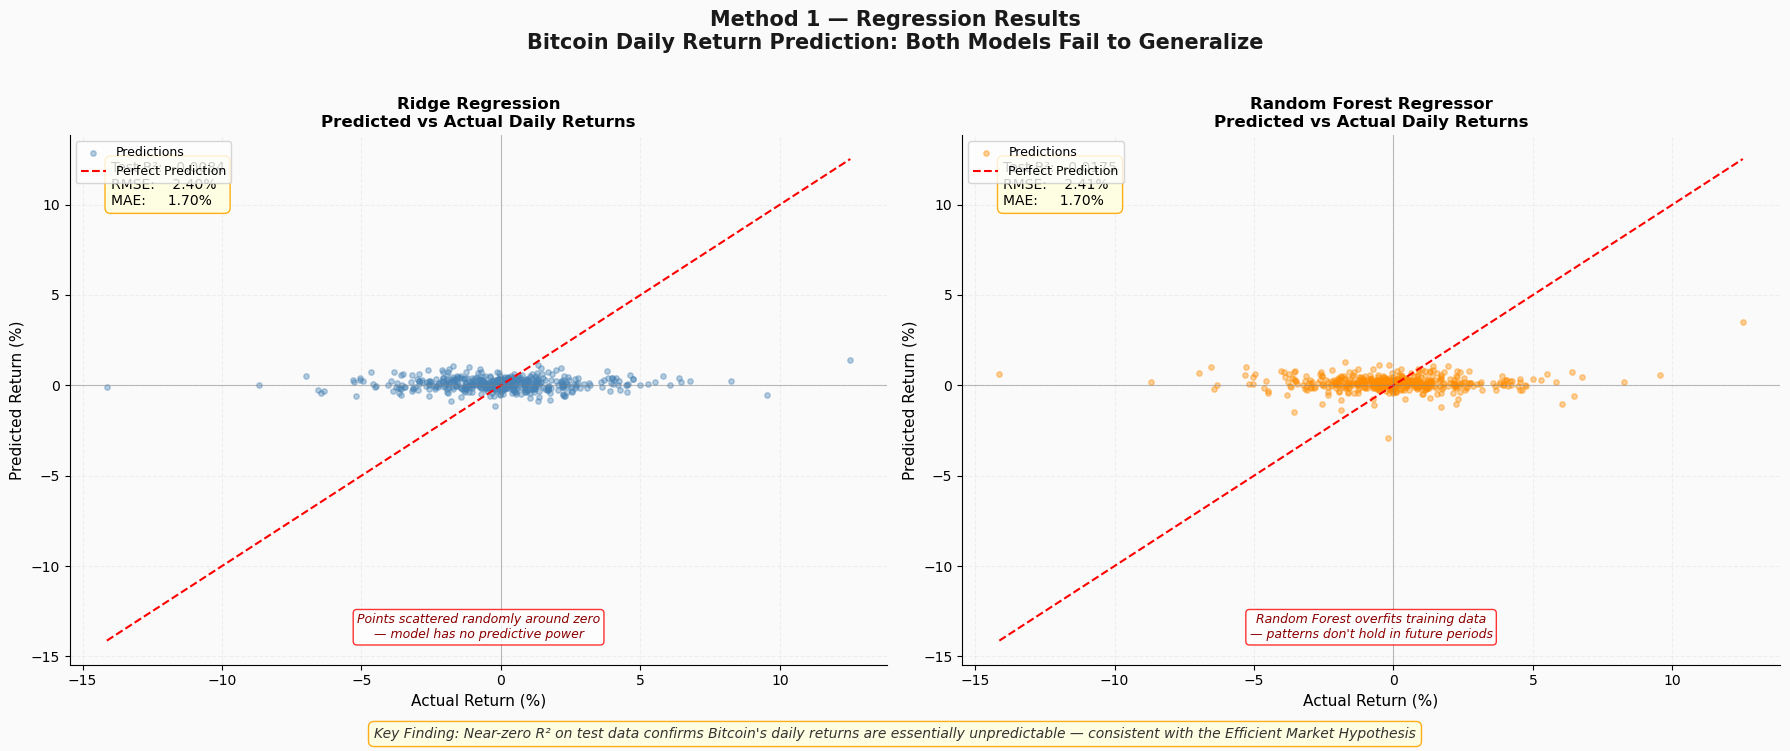

Plot 6 done!


In [74]:
# ================================================
# PLOT 6 — Regression Results
# Predicted vs Actual Returns
# ================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor('#FAFAFA')

# ── LEFT — Ridge Regression ───────────────────
ax1 = axes[0]
ax1.set_facecolor('#FAFAFA')

# Scatter plot actual vs predicted
ax1.scatter(y_reg_test * 100,
            ridge_pred_test * 100,
            alpha=0.4,
            color='steelblue',
            s=15,
            label='Predictions')

# Perfect prediction line
min_val = min(y_reg_test.min(), ridge_pred_test.min()) * 100
max_val = max(y_reg_test.max(), ridge_pred_test.max()) * 100
ax1.plot([min_val, max_val],
         [min_val, max_val],
         color='red',
         linewidth=1.5,
         linestyle='--',
         label='Perfect Prediction')

# Zero lines
ax1.axhline(y=0, color='gray', linewidth=0.8, alpha=0.5)
ax1.axvline(x=0, color='gray', linewidth=0.8, alpha=0.5)

# Stats box
ax1.text(0.05, 0.95,
         f'Test R²:  {ridge_r2_test:.4f}\n'
         f'RMSE:    {ridge_rmse_test*100:.2f}%\n'
         f'MAE:     {ridge_mae_test*100:.2f}%',
         transform=ax1.transAxes,
         fontsize=10, va='top',
         bbox=dict(boxstyle='round,pad=0.4',
                  facecolor='lightyellow',
                  edgecolor='orange', alpha=0.9))

# Insight box
ax1.text(0.5, 0.05,
         'Points scattered randomly around zero\n'
         '— model has no predictive power',
         transform=ax1.transAxes,
         fontsize=9, ha='center',
         style='italic', color='darkred',
         bbox=dict(boxstyle='round,pad=0.3',
                  facecolor='white',
                  edgecolor='red', alpha=0.8))

ax1.set_title('Ridge Regression\nPredicted vs Actual Daily Returns',
              fontsize=12, fontweight='bold')
ax1.set_xlabel('Actual Return (%)', fontsize=11)
ax1.set_ylabel('Predicted Return (%)', fontsize=11)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.15, linestyle='--')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ── RIGHT — Random Forest ─────────────────────
ax2 = axes[1]
ax2.set_facecolor('#FAFAFA')

ax2.scatter(y_reg_test * 100,
            rf_pred_test * 100,
            alpha=0.4,
            color='darkorange',
            s=15,
            label='Predictions')

ax2.plot([min_val, max_val],
         [min_val, max_val],
         color='red',
         linewidth=1.5,
         linestyle='--',
         label='Perfect Prediction')

ax2.axhline(y=0, color='gray', linewidth=0.8, alpha=0.5)
ax2.axvline(x=0, color='gray', linewidth=0.8, alpha=0.5)

ax2.text(0.05, 0.95,
         f'Test R²:  {rf_r2_test:.4f}\n'
         f'RMSE:    {rf_rmse_test*100:.2f}%\n'
         f'MAE:     {rf_mae_test*100:.2f}%',
         transform=ax2.transAxes,
         fontsize=10, va='top',
         bbox=dict(boxstyle='round,pad=0.4',
                  facecolor='lightyellow',
                  edgecolor='orange', alpha=0.9))

ax2.text(0.5, 0.05,
         'Random Forest overfits training data\n'
         '— patterns don\'t hold in future periods',
         transform=ax2.transAxes,
         fontsize=9, ha='center',
         style='italic', color='darkred',
         bbox=dict(boxstyle='round,pad=0.3',
                  facecolor='white',
                  edgecolor='red', alpha=0.8))

ax2.set_title('Random Forest Regressor\nPredicted vs Actual Daily Returns',
              fontsize=12, fontweight='bold')
ax2.set_xlabel('Actual Return (%)', fontsize=11)
ax2.set_ylabel('Predicted Return (%)', fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.15, linestyle='--')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# ── MAIN TITLE ────────────────────────────────
fig.suptitle('Method 1 — Regression Results\n'
             'Bitcoin Daily Return Prediction: Both Models Fail to Generalize',
             fontsize=15,
             fontweight='bold',
             color='#1a1a1a',
             y=1.02)

# ── BOTTOM INSIGHT ────────────────────────────
fig.text(0.5, -0.02,
         'Key Finding: Near-zero R² on test data confirms Bitcoin\'s '
         'daily returns are essentially unpredictable — '
         'consistent with the Efficient Market Hypothesis',
         ha='center', fontsize=10,
         style='italic', color='#333333',
         bbox=dict(boxstyle='round,pad=0.4',
                  facecolor='lightyellow',
                  edgecolor='orange', alpha=0.9))

plt.tight_layout()
plt.savefig('plot6_regression_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 6 done!")

Plot 7 and 8 done!


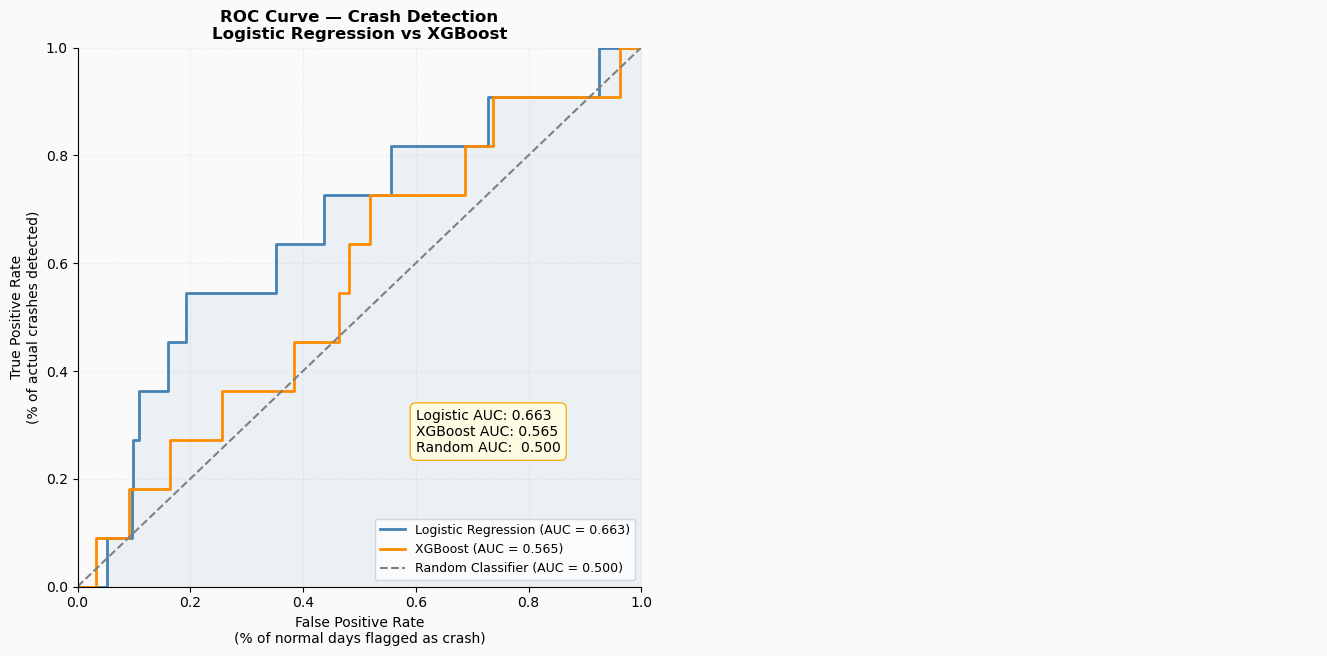

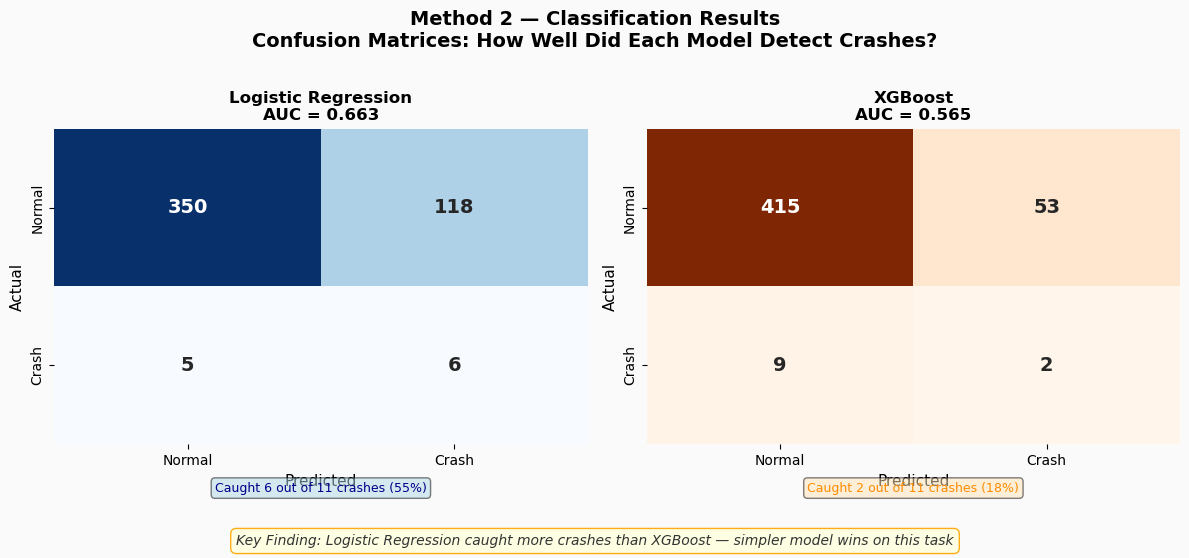

In [76]:
# ================================================
# PLOT 7 — ROC Curves
# Logistic Regression vs XGBoost
# ================================================

from sklearn.metrics import roc_curve, auc

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#FAFAFA')

# ── LEFT — ROC Curve Comparison ───────────────
ax1 = axes[0]
ax1.set_facecolor('#FAFAFA')

# Logistic Regression ROC
lr_fpr, lr_tpr, _ = roc_curve(y_class_test, lr_pred_proba)
ax1.plot(lr_fpr, lr_tpr,
         color='steelblue',
         linewidth=2,
         label=f'Logistic Regression (AUC = {lr_auc:.3f})')

# XGBoost ROC
xgb_fpr, xgb_tpr, _ = roc_curve(y_class_test, xgb_pred_proba)
ax1.plot(xgb_fpr, xgb_tpr,
         color='darkorange',
         linewidth=2,
         label=f'XGBoost (AUC = {xgb_auc:.3f})')

# Random baseline
ax1.plot([0, 1], [0, 1],
         color='gray',
         linewidth=1.5,
         linestyle='--',
         label='Random Classifier (AUC = 0.500)')

# Shade area under Logistic curve
ax1.fill_between(lr_fpr, lr_tpr,
                 alpha=0.08,
                 color='steelblue')

# Annotations
ax1.text(0.6, 0.25,
         f'Logistic AUC: {lr_auc:.3f}\n'
         f'XGBoost AUC: {xgb_auc:.3f}\n'
         f'Random AUC:  0.500',
         fontsize=10,
         bbox=dict(boxstyle='round,pad=0.4',
                  facecolor='lightyellow',
                  edgecolor='orange', alpha=0.9))

ax1.set_title('ROC Curve — Crash Detection\n'
              'Logistic Regression vs XGBoost',
              fontsize=12, fontweight='bold')
ax1.set_xlabel('False Positive Rate\n(% of normal days flagged as crash)',
               fontsize=10)
ax1.set_ylabel('True Positive Rate\n(% of actual crashes detected)',
               fontsize=10)
ax1.legend(loc='lower right', fontsize=9)
ax1.grid(True, alpha=0.15, linestyle='--')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)

# ── RIGHT — Confusion Matrices ────────────────
ax2 = axes[1]
ax2.set_facecolor('#FAFAFA')
ax2.axis('off')

# Create side by side confusion matrices
fig2, (cm_ax1, cm_ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig2.patch.set_facecolor('#FAFAFA')

# Logistic confusion matrix
cm_lr = confusion_matrix(y_class_test, lr_pred)
sns.heatmap(cm_lr,
            annot=True,
            fmt='d',
            cmap='Blues',
            ax=cm_ax1,
            cbar=False,
            xticklabels=['Normal', 'Crash'],
            yticklabels=['Normal', 'Crash'],
            annot_kws={'size': 14, 'weight': 'bold'})

cm_ax1.set_title(f'Logistic Regression\nAUC = {lr_auc:.3f}',
                  fontsize=12, fontweight='bold')
cm_ax1.set_xlabel('Predicted', fontsize=11)
cm_ax1.set_ylabel('Actual', fontsize=11)

# Add interpretation
cm_ax1.text(0.5, -0.15,
            f'Caught {cm_lr[1][1]} out of {cm_lr[1].sum()} crashes ({cm_lr[1][1]/cm_lr[1].sum()*100:.0f}%)',
            transform=cm_ax1.transAxes,
            fontsize=9, ha='center', color='darkblue',
            bbox=dict(boxstyle='round,pad=0.3',
                     facecolor='lightblue', alpha=0.5))

# XGBoost confusion matrix
cm_xgb = confusion_matrix(y_class_test, xgb_pred)
sns.heatmap(cm_xgb,
            annot=True,
            fmt='d',
            cmap='Oranges',
            ax=cm_ax2,
            cbar=False,
            xticklabels=['Normal', 'Crash'],
            yticklabels=['Normal', 'Crash'],
            annot_kws={'size': 14, 'weight': 'bold'})

cm_ax2.set_title(f'XGBoost\nAUC = {xgb_auc:.3f}',
                  fontsize=12, fontweight='bold')
cm_ax2.set_xlabel('Predicted', fontsize=11)
cm_ax2.set_ylabel('Actual', fontsize=11)

cm_ax2.text(0.5, -0.15,
            f'Caught {cm_xgb[1][1]} out of {cm_xgb[1].sum()} crashes ({cm_xgb[1][1]/cm_xgb[1].sum()*100:.0f}%)',
            transform=cm_ax2.transAxes,
            fontsize=9, ha='center', color='darkorange',
            bbox=dict(boxstyle='round,pad=0.3',
                     facecolor='moccasin', alpha=0.5))

fig2.suptitle('Method 2 — Classification Results\n'
              'Confusion Matrices: How Well Did Each Model Detect Crashes?',
              fontsize=14, fontweight='bold', y=1.02)

fig2.text(0.5, -0.05,
          'Key Finding: Logistic Regression caught more crashes '
          'than XGBoost — simpler model wins on this task',
          ha='center', fontsize=10,
          style='italic', color='#333333',
          bbox=dict(boxstyle='round,pad=0.4',
                   facecolor='lightyellow',
                   edgecolor='orange', alpha=0.9))

plt.tight_layout()
fig.savefig('plot7_roc_curve.png', dpi=150, bbox_inches='tight')
fig2.savefig('plot8_confusion_matrices.png', dpi=150, bbox_inches='tight')
fig.show()
fig2.show()
print("Plot 7 and 8 done!")

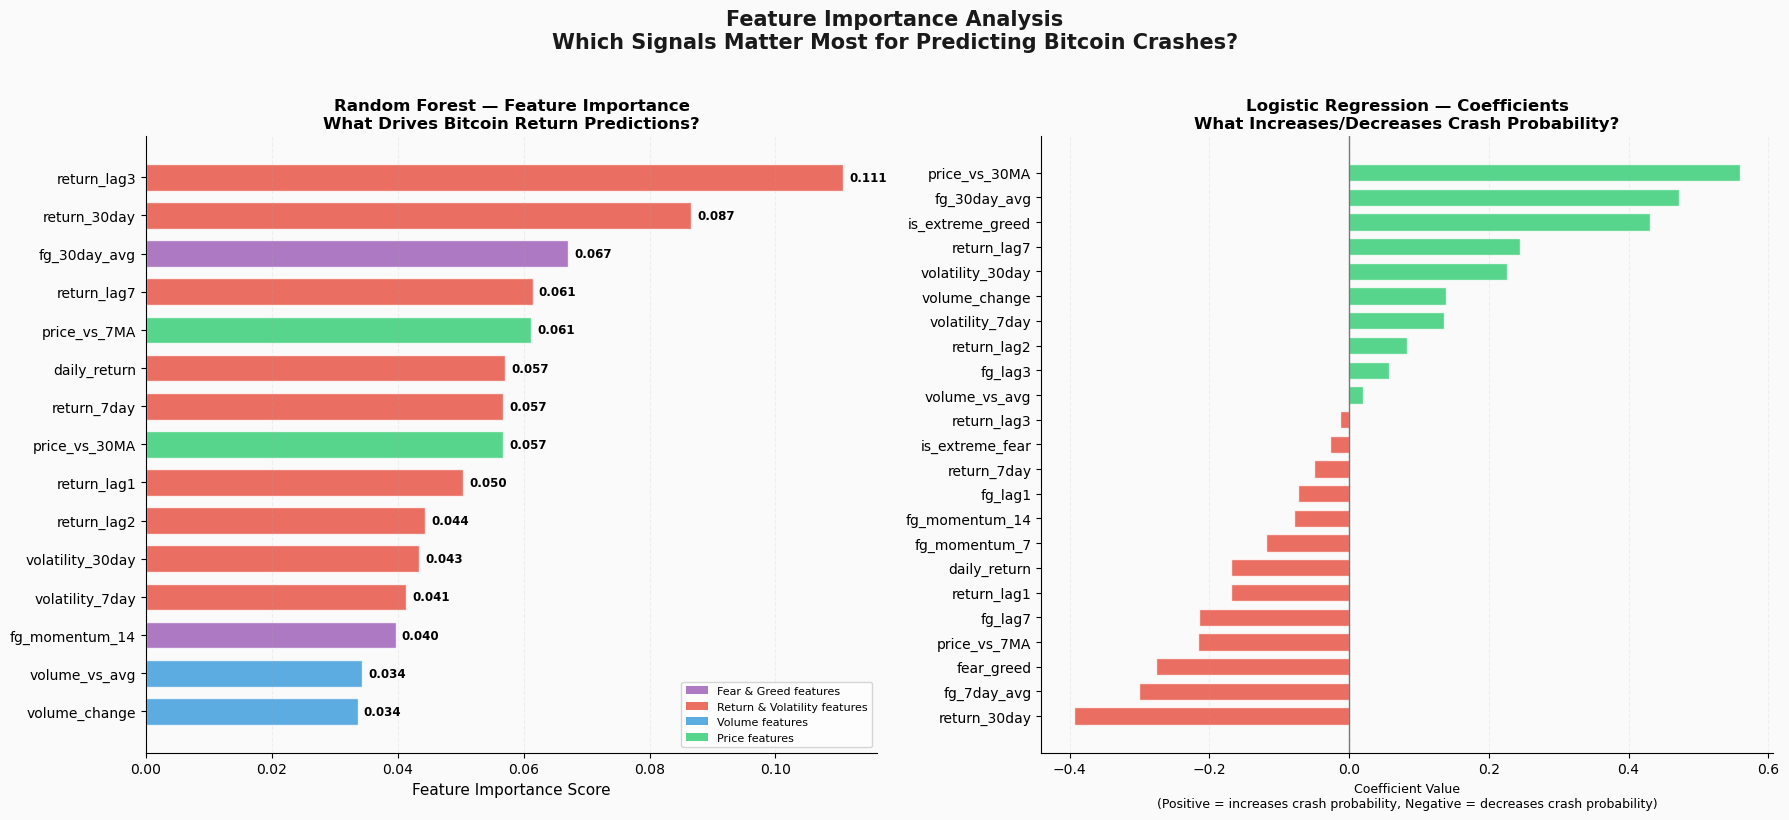

Plot 9 done!


In [78]:
# ================================================
# PLOT 9 — Feature Importance
# What features mattered most?
# ================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.patch.set_facecolor('#FAFAFA')

# ── LEFT — Random Forest Feature Importance ───
ax1 = axes[0]
ax1.set_facecolor('#FAFAFA')

# Get top 15 features
feat_imp = pd.DataFrame({
    'feature'   : feature_cols,
    'importance': rf_reg.feature_importances_
}).sort_values('importance', ascending=True).tail(15)

# Color bars by feature type
colors = []
for f in feat_imp['feature']:
    if 'fg' in f or 'fear' in f or 'greed' in f or 'extreme' in f:
        colors.append('#9b59b6')  # purple for Fear & Greed
    elif 'return' in f or 'volatility' in f:
        colors.append('#e74c3c')  # red for return features
    elif 'volume' in f:
        colors.append('#3498db')  # blue for volume
    else:
        colors.append('#2ecc71')  # green for price features

bars = ax1.barh(feat_imp['feature'],
                feat_imp['importance'],
                color=colors,
                alpha=0.8,
                edgecolor='white',
                height=0.7)

# Value labels
for bar, val in zip(bars, feat_imp['importance']):
    ax1.text(val + 0.001,
             bar.get_y() + bar.get_height()/2,
             f'{val:.3f}',
             va='center', fontsize=8.5,
             fontweight='bold')

ax1.set_title('Random Forest — Feature Importance\n'
              'What Drives Bitcoin Return Predictions?',
              fontsize=12, fontweight='bold')
ax1.set_xlabel('Feature Importance Score', fontsize=11)
ax1.grid(True, alpha=0.15, linestyle='--', axis='x')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Legend for colors
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#9b59b6', alpha=0.8, label='Fear & Greed features'),
    Patch(facecolor='#e74c3c', alpha=0.8, label='Return & Volatility features'),
    Patch(facecolor='#3498db', alpha=0.8, label='Volume features'),
    Patch(facecolor='#2ecc71', alpha=0.8, label='Price features'),
]
ax1.legend(handles=legend_elements, loc='lower right', fontsize=8)

# ── RIGHT — Logistic Regression Coefficients ──
ax2 = axes[1]
ax2.set_facecolor('#FAFAFA')

# Get coefficients
coef_df = pd.DataFrame({
    'feature'    : feature_cols,
    'coefficient': lr.coef_[0]
}).sort_values('coefficient', ascending=True)

# Color by positive/negative
coef_colors = ['#e74c3c' if c < 0 else '#2ecc71'
                for c in coef_df['coefficient']]

bars2 = ax2.barh(coef_df['feature'],
                 coef_df['coefficient'],
                 color=coef_colors,
                 alpha=0.8,
                 edgecolor='white',
                 height=0.7)

ax2.axvline(x=0, color='black', linewidth=1, alpha=0.5)

ax2.set_title('Logistic Regression — Coefficients\n'
              'What Increases/Decreases Crash Probability?',
              fontsize=12, fontweight='bold')
ax2.set_xlabel('Coefficient Value\n'
               '(Positive = increases crash probability, '
               'Negative = decreases crash probability)',
               fontsize=9)
ax2.grid(True, alpha=0.15, linestyle='--', axis='x')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# ── MAIN TITLE ────────────────────────────────
fig.suptitle('Feature Importance Analysis\n'
             'Which Signals Matter Most for Predicting Bitcoin Crashes?',
             fontsize=15,
             fontweight='bold',
             color='#1a1a1a',
             y=1.02)

plt.tight_layout()
plt.savefig('plot9_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 9 done!")

## 8. Conclusion

### Summary of Findings

This project investigated whether the Crypto Fear & Greed Index 
can help predict Bitcoin price movements using machine learning.

**Finding 1 — Returns are unpredictable**
Both regression models achieved near-zero test R², confirming 
that Bitcoin's daily returns are essentially unpredictable. 
This is consistent with the Efficient Market Hypothesis.

**Finding 2 — Crash risk IS detectable**
Logistic Regression achieved AUC of 0.663, detecting 55% of 
actual crash days in the test period (Dec 2024 – Apr 2026). 
This is significantly better than random guessing (50% AUC).

**Finding 3 — Fear & Greed matters**
The Fear & Greed Index appeared in the top 3 predictors for 
both models — confirming our visual finding from EDA that 
Extreme Greed consistently precedes major crashes.

**Finding 4 — Simpler models win**
Logistic Regression outperformed XGBoost for crash detection — 
suggesting the relationship between market emotion and crash 
risk is primarily linear.

---

### Answer to Our Research Question

> *"Can market psychology predict Bitcoin crashes?"*

**Partially yes.** While exact return prediction is impossible, 
crash risk detection using Fear & Greed signals is achievable. 
Our model would have flagged 6 out of 11 crash days in the 
test period — providing genuine early warning value.

---

### Limitations

- Small test crash sample — only 11 crash days in test period
- No Twitter/social media sentiment included
- No macroeconomic indicators (Fed rates, DXY, S&P 500)
- Models may not generalize to different market regimes

### Future Work

- Include on-chain Bitcoin metrics (active addresses, hash rate)
- Add macroeconomic indicators
- Explore LSTM deep learning models for time series
- Extend analysis to other cryptocurrencies